# SimEMG EDA (Mendeley yx5pb66hwz.1)

이 노트북은 `data/SimEMG`의 `.mat` 파일을 대상으로:
- 데이터 커버리지/결측/길이/진폭/QC 요약
- 모달리티(lead I / Ag-AgCl / ORB)별 시계열/주파수 특성 비교
- 모션/접촉/EMG 혼입 프록시 지표 산출(웨어러블 도메인 시프트 근거)
- 리뷰어 코멘트(외부 일반화/데이터 다양성) 대응 문단 초안 자동 생성

**Dataset (SimEMG)**
- Simultaneous recordings of noise-free and EMG-noise contaminated ECG
- Sampling rate: 500 Hz
- Amplitude resolution: 200 samples per mV
- 14 subjects, 110 pairs (dataset description 기준)

참고: https://data.mendeley.com/datasets/yx5pb66hwz/1

## 1. 환경 설정 및 데이터 경로 구성 (SimEMG / Mendeley)

In [1]:
from __future__ import annotations

import os
import re
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

# Reproducibility
np.random.seed(1234)

# Paths
REPO_ROOT = Path.cwd()  # assumes notebook is run from repo root
SIMEMG_DIR = REPO_ROOT / "data" / "SimEMG"
OUT_DIR = REPO_ROOT / "output_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Dataset constants from SimEMG description
FS_HZ = 500
SAMPLES_PER_MV = 200

# Plot defaults
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

print("REPO_ROOT:", REPO_ROOT)
print("SIMEMG_DIR exists:", SIMEMG_DIR.exists(), "->", SIMEMG_DIR)
print("#mat files:", len(list(SIMEMG_DIR.glob('*.mat'))))

/tmp/ipykernel_2334786/1372989018.py:12: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.3)
  from scipy.io import loadmat


REPO_ROOT: /home/dhc99/ecg_denoise
SIMEMG_DIR exists: True -> /home/dhc99/ecg_denoise/data/SimEMG
#mat files: 110


In [2]:
import numpy as _np
import scipy as _scipy
print("numpy:", _np.__version__)
print("scipy:", _scipy.__version__)

numpy: 2.3.3
scipy: 1.14.1


## 2. `.mat` 파일 검색 및 레코드 매니페스트(DataFrame) 생성

In [3]:
MAT_PATTERN = re.compile(r"^P(?P<subject>\d+)_(?P<session>\d+)_(?P<modality>.+)\.mat$")

rows = []
for p in sorted(SIMEMG_DIR.glob("*.mat")):
    m = MAT_PATTERN.match(p.name)
    if not m:
        rows.append({"path": p, "subject": None, "session": None, "modality": None, "parse_ok": False})
        continue
    rows.append({
        "path": p,
        "subject": int(m.group("subject")),
        "session": int(m.group("session")),
        "modality": m.group("modality"),
        "parse_ok": True,
    })

files_df = pd.DataFrame(rows)
print("parse_ok:", files_df["parse_ok"].mean())
print(files_df.head(3))

# Pivot so each (subject, session) is one row with up to 3 modalities
manifest = (
    files_df[files_df["parse_ok"]]
    .copy()
    .assign(modality=lambda d: d["modality"].str.strip())
    .pivot_table(index=["subject", "session"], columns="modality", values="path", aggfunc="first")
    .reset_index()
)

# Normalize known modality column names (keep original as-is, but add canonical names)
KNOWN_MODALITIES = ["lead I", "Ag-AgCl", "ORB"]
for k in KNOWN_MODALITIES:
    if k not in manifest.columns:
        manifest[k] = pd.NA

manifest = manifest[["subject", "session"] + KNOWN_MODALITIES]

print("#subjects:", manifest["subject"].nunique())
print("#sessions:", len(manifest))
missing_rate = manifest[KNOWN_MODALITIES].isna().mean().sort_values(ascending=False)
print("Missing rate by modality:\n", missing_rate)

manifest.head()

parse_ok: 1.0
                                                path  subject  session  \
0  /home/dhc99/ecg_denoise/data/SimEMG/P10_1_Ag-A...       10        1   
1  /home/dhc99/ecg_denoise/data/SimEMG/P10_1_ORB.mat       10        1   
2  /home/dhc99/ecg_denoise/data/SimEMG/P10_1_lead...       10        1   

  modality  parse_ok  
0  Ag-AgCl      True  
1      ORB      True  
2   lead I      True  
#subjects: 14
#sessions: 37
Missing rate by modality:
 modality
lead I     0.027027
Ag-AgCl    0.000000
ORB        0.000000
dtype: float64


modality,subject,session,lead I,Ag-AgCl,ORB
0,1,1,/home/dhc99/ecg_denoise/data/SimEMG/P1_1_lead ...,/home/dhc99/ecg_denoise/data/SimEMG/P1_1_Ag-Ag...,/home/dhc99/ecg_denoise/data/SimEMG/P1_1_ORB.mat
1,1,2,/home/dhc99/ecg_denoise/data/SimEMG/P1_2_lead ...,/home/dhc99/ecg_denoise/data/SimEMG/P1_2_Ag-Ag...,/home/dhc99/ecg_denoise/data/SimEMG/P1_2_ORB.mat
2,1,3,/home/dhc99/ecg_denoise/data/SimEMG/P1_3_lead ...,/home/dhc99/ecg_denoise/data/SimEMG/P1_3_Ag-Ag...,/home/dhc99/ecg_denoise/data/SimEMG/P1_3_ORB.mat
3,2,1,/home/dhc99/ecg_denoise/data/SimEMG/P2_1_lead ...,/home/dhc99/ecg_denoise/data/SimEMG/P2_1_Ag-Ag...,/home/dhc99/ecg_denoise/data/SimEMG/P2_1_ORB.mat
4,2,2,/home/dhc99/ecg_denoise/data/SimEMG/P2_2_lead ...,/home/dhc99/ecg_denoise/data/SimEMG/P2_2_Ag-Ag...,/home/dhc99/ecg_denoise/data/SimEMG/P2_2_ORB.mat


## 3. `.mat` 내부 구조(키/형태) 점검 + 로더 함수 구현

In [4]:
def _is_numeric_ndarray(x) -> bool:
    return isinstance(x, np.ndarray) and np.issubdtype(x.dtype, np.number)


def load_simemg_mat(path: Path) -> np.ndarray:
    """Load SimEMG .mat and return a numeric array shaped (N, 2).

    Strategy:
    - loadmat
    - among non-metadata keys, select the largest numeric ndarray
    - squeeze singleton dims
    - ensure 2 columns (if transposed, fix)
    """
    d = loadmat(path)
    keys = [k for k in d.keys() if not k.startswith("__")]
    candidates = []
    for k in keys:
        v = d[k]
        if _is_numeric_ndarray(v):
            candidates.append((k, v))

    if not candidates:
        raise ValueError(f"No numeric arrays found in {path}")

    # pick the largest by number of elements
    k_best, arr = max(candidates, key=lambda kv: kv[1].size)
    arr = np.asarray(arr).squeeze()

    if arr.ndim == 1:
        # Not expected, but normalize to (N, 1)
        arr = arr.reshape(-1, 1)

    if arr.ndim != 2:
        raise ValueError(f"Unexpected ndim={arr.ndim} for {path} key={k_best} shape={arr.shape}")

    # Ensure (N, 2)
    if arr.shape[1] == 2:
        pass
    elif arr.shape[0] == 2:
        arr = arr.T
    else:
        raise ValueError(f"Expected 2-channel array in {path} key={k_best}, got shape={arr.shape}")

    return arr.astype(np.float64, copy=False)


def hf_energy_ratio(x: np.ndarray, fs_hz: int = FS_HZ, f0_hz: float = 40.0) -> float:
    """High-frequency energy ratio proxy using numpy FFT."""
    x = np.asarray(x, dtype=np.float64)
    x = x - np.nanmean(x)
    n = x.shape[0]
    if n < 8:
        return np.nan

    freqs = np.fft.rfftfreq(n, d=1.0 / fs_hz)
    spec = np.fft.rfft(x)
    pxx = (np.abs(spec) ** 2) / n

    total = np.nansum(pxx)
    if total <= 0:
        return np.nan

    hf = np.nansum(pxx[freqs >= f0_hz])
    return float(hf / total)


def infer_clean_noisy(x2: np.ndarray, fs_hz: int = FS_HZ) -> tuple[np.ndarray, np.ndarray, dict]:
    """Infer which column is clean vs noisy using HF energy ratio.

    Returns: clean, noisy, info
    """
    if x2.shape[1] != 2:
        raise ValueError(f"Expected (N,2), got {x2.shape}")

    c0 = x2[:, 0]
    c1 = x2[:, 1]
    r0 = hf_energy_ratio(c0, fs_hz=fs_hz)
    r1 = hf_energy_ratio(c1, fs_hz=fs_hz)

    # Assume noisy has higher HF ratio (more EMG contamination)
    if np.isnan(r0) or np.isnan(r1):
        # fallback: higher variance is noisy
        if np.nanvar(c0) <= np.nanvar(c1):
            clean, noisy = c0, c1
        else:
            clean, noisy = c1, c0
    else:
        if r0 <= r1:
            clean, noisy = c0, c1
        else:
            clean, noisy = c1, c0

    info = {"hf_ratio_col0": r0, "hf_ratio_col1": r1}
    return clean, noisy, info


# Quick structure check on a few files
sample_paths = files_df[files_df["parse_ok"]].sample(min(5, len(files_df)), random_state=0)["path"].tolist()
for p in sample_paths:
    arr = load_simemg_mat(Path(p))
    clean, noisy, info = infer_clean_noisy(arr)
    print(Path(p).name, "shape", arr.shape, "hf", info)


P6_1_lead I.mat shape (15000, 2) hf {'hf_ratio_col0': 0.0027966467890886246, 'hf_ratio_col1': 0.013029808332456027}
P11_3_ORB.mat shape (15000, 2) hf {'hf_ratio_col0': 0.003653105892365948, 'hf_ratio_col1': 0.005674584446529982}
P4_3_ORB.mat shape (15000, 2) hf {'hf_ratio_col0': 0.008867826848719867, 'hf_ratio_col1': 0.22758954768403128}
P10_1_lead I.mat shape (15000, 2) hf {'hf_ratio_col0': 0.007081780805287077, 'hf_ratio_col1': 0.04712512740917955}
P14_1_ORB.mat shape (15000, 2) hf {'hf_ratio_col0': 0.010549072468740176, 'hf_ratio_col1': 0.022841906566800557}


## 4. 신호 길이/샘플링레이트/결측 여부 등 기본 QC(품질검사)

- 길이, NaN/Inf, min/max, RMS, 클리핑/상수구간 의심 지표 등을 계산합니다.
- SimEMG 설명상 샘플링레이트는 500 Hz이며, 값은 200 samples/mV 해상도를 가집니다(필요 시 mV로 환산 가능).

In [5]:
def clipping_suspect_ratio(x: np.ndarray) -> float:
    """Heuristic: fraction of samples that equal the most common rounded value."""
    x = np.asarray(x, dtype=np.float64)
    if x.size == 0:
        return np.nan
    xr = np.round(x, 3)
    vals, counts = np.unique(xr, return_counts=True)
    return float(counts.max() / x.size)


def spike_rate(x: np.ndarray, z_thresh: float = 6.0) -> float:
    x = np.asarray(x, dtype=np.float64)
    x = x - np.nanmean(x)
    dx = np.diff(x)
    sd = np.nanstd(dx)
    if not np.isfinite(sd) or sd == 0:
        return 0.0
    z = np.abs(dx) / sd
    return float(np.mean(z > z_thresh))


def bandpower_ratio(x: np.ndarray, fs_hz: int, f_lo: float, f_hi: float) -> float:
    x = np.asarray(x, dtype=np.float64)
    x = x - np.nanmean(x)
    n = x.shape[0]
    if n < 8:
        return np.nan
    freqs = np.fft.rfftfreq(n, d=1.0 / fs_hz)
    spec = np.fft.rfft(x)
    pxx = (np.abs(spec) ** 2) / n
    total = np.nansum(pxx)
    if total <= 0:
        return np.nan
    m = (freqs >= f_lo) & (freqs < f_hi)
    return float(np.nansum(pxx[m]) / total)


def estimate_snr_db(clean: np.ndarray, noisy: np.ndarray) -> float:
    clean = np.asarray(clean, dtype=np.float64)
    noisy = np.asarray(noisy, dtype=np.float64)
    noise = noisy - clean
    ps = np.nanvar(clean)
    pn = np.nanvar(noise)
    if ps <= 0 or pn <= 0:
        return np.nan
    return float(10.0 * np.log10(ps / pn))


qc_rows = []
for _, r in files_df[files_df["parse_ok"]].iterrows():
    path = Path(r["path"])
    try:
        arr = load_simemg_mat(path)
        clean, noisy, info = infer_clean_noisy(arr)

        n = int(arr.shape[0])
        duration = n / FS_HZ

        # Convert to mV for amplitude stats if desired
        clean_mv = clean / SAMPLES_PER_MV
        noisy_mv = noisy / SAMPLES_PER_MV

        qc_rows.append({
            "path": str(path),
            "subject": int(r["subject"]),
            "session": int(r["session"]),
            "modality": str(r["modality"]).strip(),
            "n": n,
            "duration_sec": duration,
            "nan_count": int(np.isnan(arr).sum()),
            "inf_count": int(np.isinf(arr).sum()),
            "clean_std_mv": float(np.nanstd(clean_mv)),
            "noisy_std_mv": float(np.nanstd(noisy_mv)),
            "snr_db_est": estimate_snr_db(clean, noisy),
            "hf_ratio_clean": hf_energy_ratio(clean, fs_hz=FS_HZ),
            "hf_ratio_noisy": hf_energy_ratio(noisy, fs_hz=FS_HZ),
            "baseline_ratio_0_0p5": bandpower_ratio(noisy, FS_HZ, 0.0, 0.5),
            "ecg_ratio_0p5_40": bandpower_ratio(noisy, FS_HZ, 0.5, 40.0),
            "hf_ratio_40_150": bandpower_ratio(noisy, FS_HZ, 40.0, 150.0),
            "clip_ratio_noisy": clipping_suspect_ratio(noisy),
            "spike_rate_noisy": spike_rate(noisy),
            "loader_hf_col0": info.get("hf_ratio_col0"),
            "loader_hf_col1": info.get("hf_ratio_col1"),
        })
    except Exception as e:
        qc_rows.append({
            "path": str(path),
            "subject": int(r["subject"]),
            "session": int(r["session"]),
            "modality": str(r["modality"]).strip(),
            "error": repr(e),
        })

qc_df = pd.DataFrame(qc_rows)
print("QC rows:", len(qc_df))
print("Errors:", qc_df["error"].notna().sum() if "error" in qc_df.columns else 0)
qc_df.head()

QC rows: 110
Errors: 0


,path,subject,session,modality,n,duration_sec,nan_count,inf_count,clean_std_mv,noisy_std_mv,snr_db_est,hf_ratio_clean,hf_ratio_noisy,baseline_ratio_0_0p5,ecg_ratio_0p5_40,hf_ratio_40_150,clip_ratio_noisy,spike_rate_noisy,loader_hf_col0,loader_hf_col1
0,/home/dhc99/ecg_denoise/data/SimEMG/P10_1_Ag-A...,10,1,Ag-AgCl,15000,30.0,0,0,0.103028,0.110751,10.058547,0.007082,0.055157,0.000026,0.944817,0.055045,0.000333,0.000000,0.007082,0.055157
1,/home/dhc99/ecg_denoise/data/SimEMG/P10_1_ORB.mat,10,1,ORB,15000,30.0,0,0,0.103028,0.110817,10.504639,0.007082,0.049362,0.000046,0.950592,0.049204,0.000333,0.000067,0.007082,0.049362
2,/home/dhc99/ecg_denoise/data/SimEMG/P10_1_lead...,10,1,lead I,15000,30.0,0,0,0.103028,0.110504,10.777483,0.007082,0.047125,0.000010,0.952865,0.047071,0.000400,0.000133,0.007082,0.047125
3,/home/dhc99/ecg_denoise/data/SimEMG/P11_1_Ag-A...,11,1,Ag-AgCl,15000,30.0,0,0,0.162638,0.170789,11.887613,0.002314,0.040364,0.000005,0.959630,0.040320,0.000333,0.000267,0.002314,0.040364
4,/home/dhc99/ecg_denoise/data/SimEMG/P11_1_ORB.mat,11,1,ORB,15000,30.0,0,0,0.162638,0.174836,9.381617,0.002314,0.038992,0.000054,0.960954,0.038950,0.000333,0.000267,0.002314,0.038992


## 5. 모달리티별(Ag-AgCl / ORB / lead I) 커버리지 및 분포 요약

Rows with any missing modality: 1 / 37


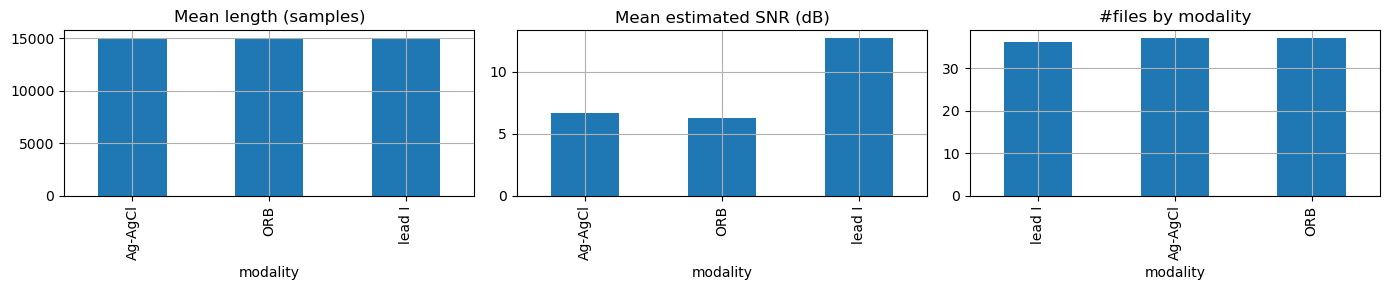

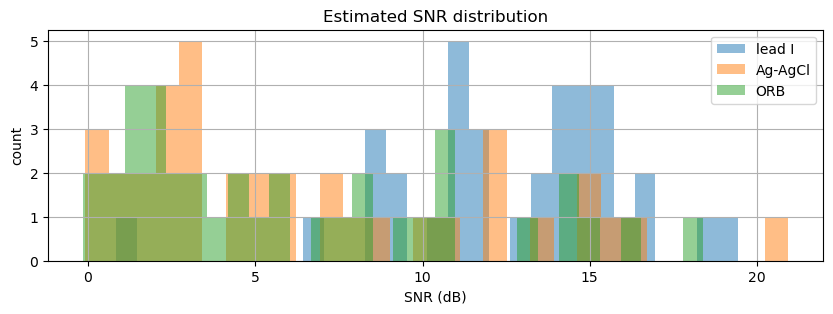

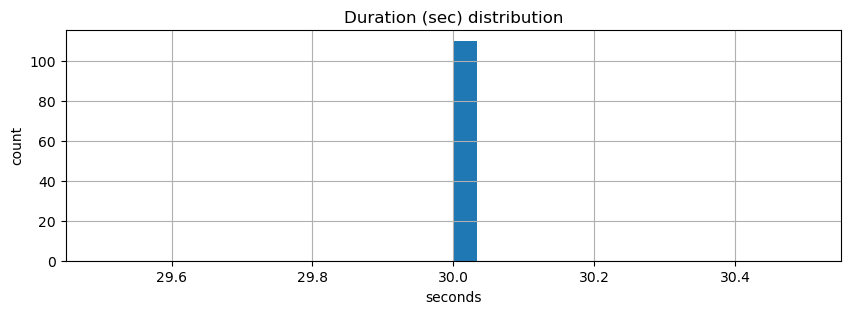

modality,subject,session,lead I,Ag-AgCl,ORB,missing_any
31,13,1,NaN,/home/dhc99/ecg_denoise/data/SimEMG/P13_1_Ag-A...,/home/dhc99/ecg_denoise/data/SimEMG/P13_1_ORB.mat,True


In [6]:
ok = qc_df[qc_df.get("error").isna()] if "error" in qc_df.columns else qc_df

# Coverage (from manifest)
coverage = manifest.copy()
coverage["missing_any"] = coverage[KNOWN_MODALITIES].isna().any(axis=1)
print("Rows with any missing modality:", int(coverage["missing_any"].sum()), "/", len(coverage))

# Basic distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

(ok.groupby("modality")["n"].mean().sort_index()).plot(kind="bar", ax=axes[0], title="Mean length (samples)")
(ok.groupby("modality")["snr_db_est"].mean().sort_index()).plot(kind="bar", ax=axes[1], title="Mean estimated SNR (dB)")
(ok["modality"].value_counts().reindex(KNOWN_MODALITIES).plot(kind="bar", ax=axes[2], title="#files by modality"))

plt.tight_layout()
plt.show()

# SNR histogram by modality
plt.figure(figsize=(10, 3))
for m in KNOWN_MODALITIES:
    s = ok.loc[ok["modality"] == m, "snr_db_est"].dropna()
    if len(s) == 0:
        continue
    plt.hist(s, bins=30, alpha=0.5, label=m)
plt.title("Estimated SNR distribution")
plt.xlabel("SNR (dB)")
plt.ylabel("count")
plt.legend()
plt.show()

# Duration distribution
plt.figure(figsize=(10, 3))
plt.hist(ok["duration_sec"].dropna(), bins=30)
plt.title("Duration (sec) distribution")
plt.xlabel("seconds")
plt.ylabel("count")
plt.show()

# Missing modality list (if any)
missing_rows = coverage[coverage[KNOWN_MODALITIES].isna().any(axis=1)]
missing_rows.head()

## 6. 대표 샘플 타임시리즈 시각화(피험자/세션/모달리티 비교)

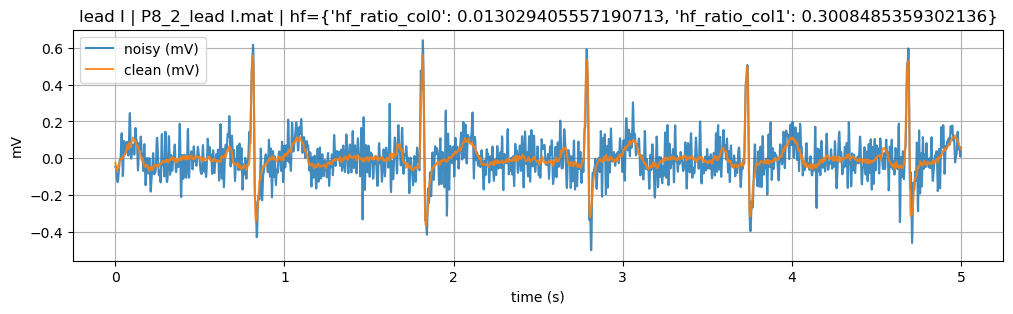

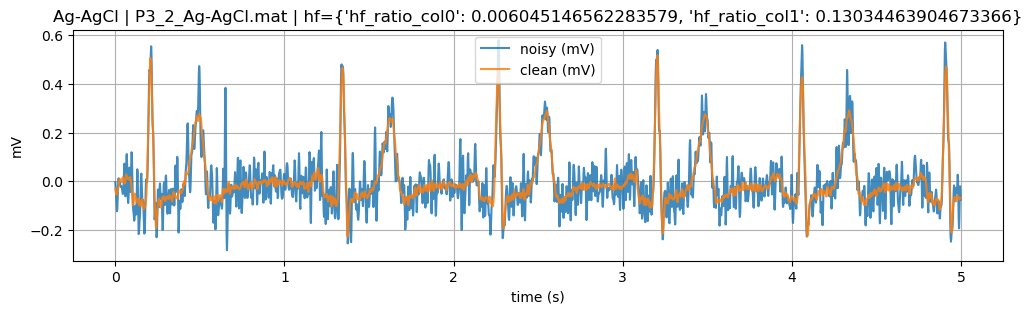

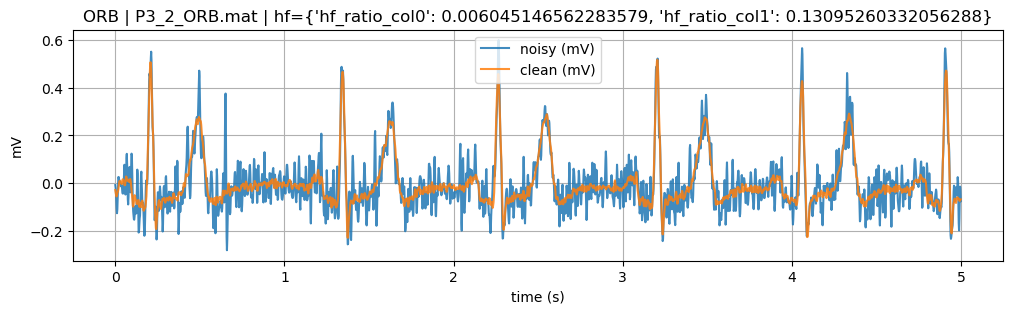

Top spike_rate examples:
                                                 path modality  \
92  /home/dhc99/ecg_denoise/data/SimEMG/P8_1_Ag-Ag...  Ag-AgCl   
94  /home/dhc99/ecg_denoise/data/SimEMG/P8_1_lead ...   lead I   
93   /home/dhc99/ecg_denoise/data/SimEMG/P8_1_ORB.mat      ORB   

    spike_rate_noisy  snr_db_est  
92          0.007334   15.446716  
94          0.007134   14.113684  
93          0.007067   14.273732  


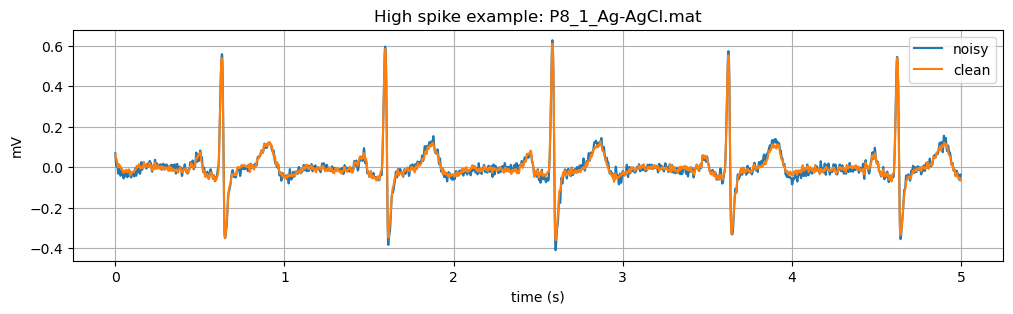

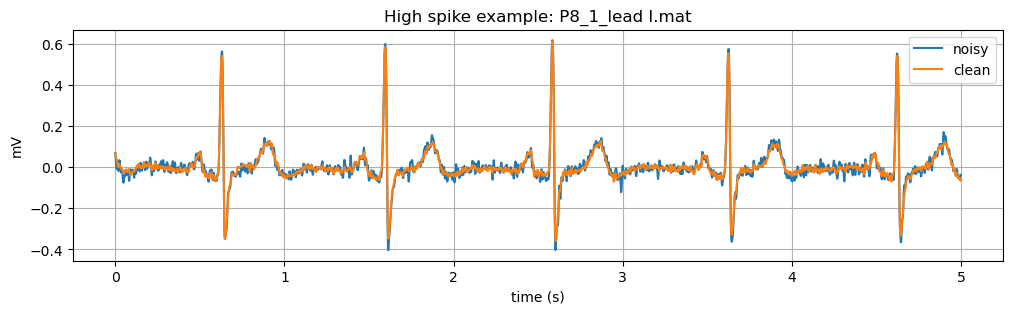

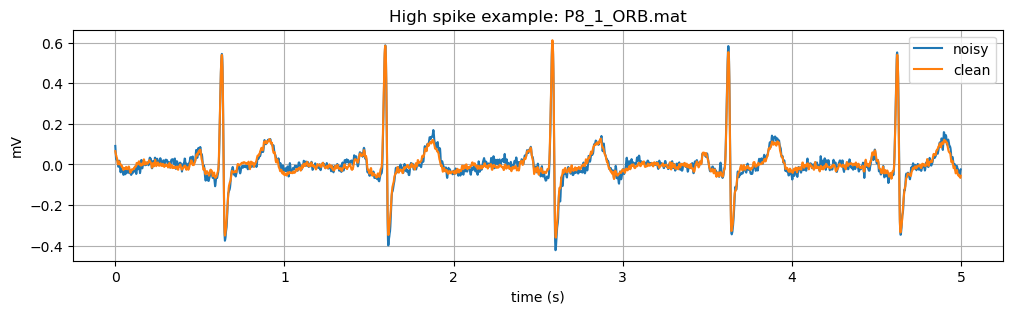

In [7]:
def plot_example_for_modality(modality: str, seconds: float = 5.0):
    subset = ok[ok["modality"] == modality]
    if len(subset) == 0:
        print("No rows for modality", modality)
        return
    row = subset.sample(1, random_state=0).iloc[0]
    path = Path(row["path"])
    arr = load_simemg_mat(path)
    clean, noisy, info = infer_clean_noisy(arr)

    n = min(int(seconds * FS_HZ), arr.shape[0])
    t = np.arange(n) / FS_HZ

    clean_mv = clean[:n] / SAMPLES_PER_MV
    noisy_mv = noisy[:n] / SAMPLES_PER_MV

    plt.figure(figsize=(12, 3))
    plt.plot(t, noisy_mv, label="noisy (mV)", alpha=0.85)
    plt.plot(t, clean_mv, label="clean (mV)", alpha=0.85)
    plt.title(f"{modality} | {path.name} | hf={info}")
    plt.xlabel("time (s)")
    plt.ylabel("mV")
    plt.legend()
    plt.show()


for m in KNOWN_MODALITIES:
    plot_example_for_modality(m, seconds=5.0)

# Auto-find some high-spike examples
candidates = ok.sort_values("spike_rate_noisy", ascending=False).head(3)
print("Top spike_rate examples:")
print(candidates[["path", "modality", "spike_rate_noisy", "snr_db_est"]])

for p in candidates["path"].tolist():
    path = Path(p)
    arr = load_simemg_mat(path)
    clean, noisy, _ = infer_clean_noisy(arr)
    n = min(int(5 * FS_HZ), arr.shape[0])
    t = np.arange(n) / FS_HZ
    plt.figure(figsize=(12, 3))
    plt.plot(t, (noisy[:n] / SAMPLES_PER_MV), label="noisy")
    plt.plot(t, (clean[:n] / SAMPLES_PER_MV), label="clean")
    plt.title(f"High spike example: {path.name}")
    plt.xlabel("time (s)")
    plt.ylabel("mV")
    plt.legend()
    plt.show()

## 7. 주파수영역 EDA: PSD, 대역 파워(저주파/EMG 대역)

여기서는 SciPy `signal.welch` 대신 numpy FFT 기반의 간단 PSD(상대 비교 목적)를 사용합니다.

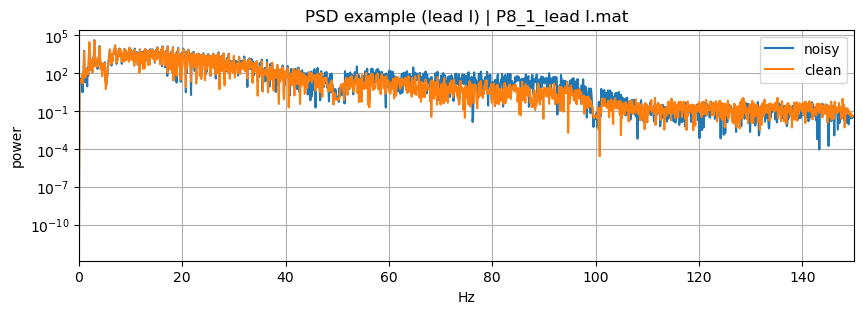

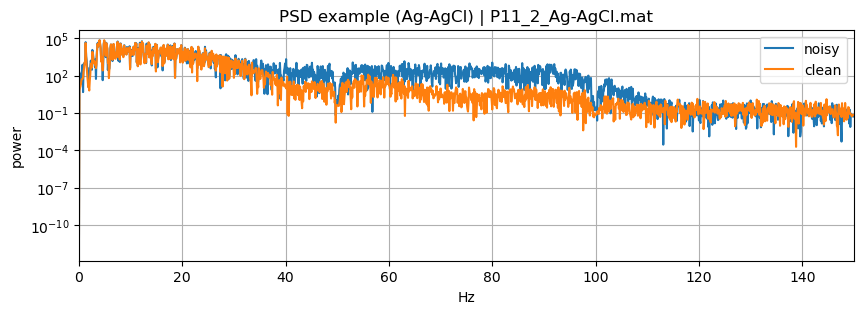

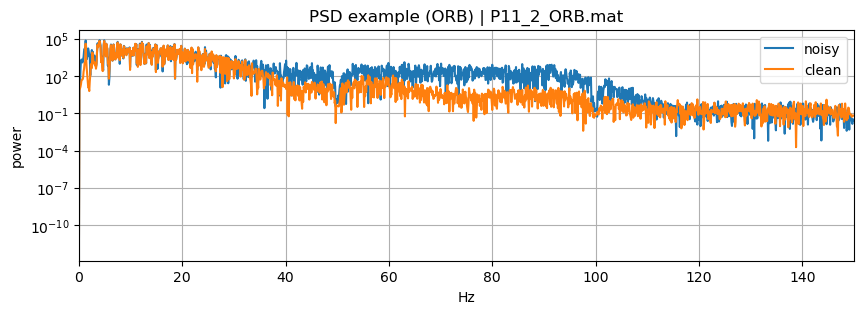

baseline_ratio_0_0p5                     ecg_ratio_0p5_40            \
                         mean       std    median             mean       std   
modality                                                                       
Ag-AgCl              0.000086  0.000131  0.000027         0.841114  0.106583   
ORB                  0.000120  0.000134  0.000072         0.843402  0.104897   
lead I               0.000087  0.000169  0.000013         0.953978  0.049706   

                   hf_ratio_40_150                     snr_db_est            \
            median            mean       std    median       mean       std   
modality                                                                      
Ag-AgCl   0.830854        0.158708  0.106582  0.169094   6.623714  5.505679   
ORB       0.831492        0.156387  0.104886  0.168449   6.218374  5.130243   
lead I    0.966850        0.045872  0.049711  0.033038  12.682592  3.579295   

                     
             median  
modality             
Ag-AgCl    4.851363  
ORB        4.646043  
lead I    13.628770

In [8]:
def simple_psd(x: np.ndarray, fs_hz: int = FS_HZ):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.nanmean(x)
    n = x.shape[0]
    freqs = np.fft.rfftfreq(n, d=1.0 / fs_hz)
    spec = np.fft.rfft(x)
    pxx = (np.abs(spec) ** 2) / n
    return freqs, pxx


def plot_psd_example(modality: str, seconds: float = 10.0):
    subset = ok[ok["modality"] == modality]
    if len(subset) == 0:
        return
    row = subset.sample(1, random_state=1).iloc[0]
    path = Path(row["path"])
    arr = load_simemg_mat(path)
    clean, noisy, _ = infer_clean_noisy(arr)

    n = min(int(seconds * FS_HZ), arr.shape[0])
    f1, p1 = simple_psd(clean[:n], fs_hz=FS_HZ)
    f2, p2 = simple_psd(noisy[:n], fs_hz=FS_HZ)

    plt.figure(figsize=(10, 3))
    plt.semilogy(f2, p2 + 1e-12, label="noisy")
    plt.semilogy(f1, p1 + 1e-12, label="clean")
    plt.xlim(0, 150)
    plt.xlabel("Hz")
    plt.ylabel("power")
    plt.title(f"PSD example ({modality}) | {path.name}")
    plt.legend()
    plt.show()


for m in KNOWN_MODALITIES:
    plot_psd_example(m, seconds=10.0)

# Bandpower proxy summary by modality
bp_cols = ["baseline_ratio_0_0p5", "ecg_ratio_0p5_40", "hf_ratio_40_150"]
summary = ok.groupby("modality")[bp_cols + ["snr_db_est"]].agg(["mean", "std", "median"])
summary

## 8. 모달리티 간 유사도: 상관/코히어런스/정렬(길이 매칭)

- 동일 subject/session에서 모달리티 쌍에 대한 상관/시간지연(옵션)/코히어런스(근사)를 계산합니다.
- 코히어런스는 SciPy가 가능하면 `scipy.signal.coherence`를 사용하고, 아니면 간단 FFT 기반 근사치를 사용합니다.

In [ ]:
from itertools import combinations

try:
    from scipy.signal import coherence as scipy_coherence  # type: ignore
except Exception:
    scipy_coherence = None


def coherence_proxy(x: np.ndarray, y: np.ndarray, fs_hz: int = FS_HZ, fmax_hz: float = 150.0):
    """Return freqs and magnitude-squared coherence.

    Prefer scipy.signal.coherence if available; otherwise use a simple FFT-based estimate.
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    n = min(len(x), len(y))
    x = x[:n] - np.mean(x[:n])
    y = y[:n] - np.mean(y[:n])

    if scipy_coherence is not None:
        f, cxy = scipy_coherence(x, y, fs=fs_hz, nperseg=min(2048, n))
        m = f <= fmax_hz
        return f[m], cxy[m]

    # Simple single-segment estimate (rough proxy)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs_hz)
    X = np.fft.rfft(x)
    Y = np.fft.rfft(y)
    Sxx = (np.abs(X) ** 2)
    Syy = (np.abs(Y) ** 2)
    Sxy = X * np.conj(Y)
    cxy = (np.abs(Sxy) ** 2) / (Sxx * Syy + 1e-12)
    m = freqs <= fmax_hz
    return freqs[m], cxy[m]


def get_clean_signal_for(manifest_row: pd.Series, modality: str) -> np.ndarray | None:
    p = manifest_row.get(modality)
    if pd.isna(p):
        return None
    arr = load_simemg_mat(Path(p))
    clean, noisy, _ = infer_clean_noisy(arr)
    return clean


sim_rows = []
for _, r in manifest.iterrows():
    subject = int(r["subject"])
    session = int(r["session"])

    signals = {}
    for m in KNOWN_MODALITIES:
        sig = get_clean_signal_for(r, m)
        if sig is not None:
            signals[m] = sig

    for a, b in combinations(sorted(signals.keys()), 2):
        x = signals[a]
        y = signals[b]
        n = min(len(x), len(y))
        if n < FS_HZ * 2:
            continue
        x = x[:n]
        y = y[:n]

        corr = float(np.corrcoef(x, y)[0, 1])

        # simple lag estimate (argmax of normalized cross-correlation within +/- 0.5s)
        max_lag = int(0.5 * FS_HZ)
        x0 = x - np.mean(x)
        y0 = y - np.mean(y)
        cc = np.correlate(x0, y0, mode="full")
        mid = len(cc) // 2
        window = cc[mid - max_lag : mid + max_lag + 1]
        lag = int(np.argmax(window) - max_lag)
        lag_ms = 1000.0 * lag / FS_HZ

        f, cxy = coherence_proxy(x, y)
        coh_mean_0_40 = float(np.nanmean(cxy[(f >= 0.5) & (f <= 40.0)])) if len(f) else np.nan

        sim_rows.append({
            "subject": subject,
            "session": session,
            "pair": f"{a} vs {b}",
            "corr": corr,
            "lag_ms": lag_ms,
            "coh_mean_0p5_40": coh_mean_0_40,
        })

sim_df = pd.DataFrame(sim_rows)
print("Pairs computed:", len(sim_df))
sim_df.head()

## 9. 웨어러블/크로스DB 도메인 시프트를 위한 프록시 지표 산출(노이즈·아티팩트 지표)

리뷰 대응 근거로, 실제 웨어러블에서 흔히 커지는 요인(베이스라인 드리프트, EMG/HF 혼입, 스파이크)을 간단 프록시로 요약합니다.

In [ ]:
# Proxy metric distributions (computed already in qc_df)
proxy_cols = ["baseline_ratio_0_0p5", "hf_ratio_40_150", "spike_rate_noisy", "clip_ratio_noisy"]

fig, axes = plt.subplots(1, len(proxy_cols), figsize=(16, 3))
for ax, col in zip(axes, proxy_cols):
    for m in KNOWN_MODALITIES:
        s = ok.loc[ok["modality"] == m, col].dropna()
        if len(s) == 0:
            continue
        ax.hist(s, bins=30, alpha=0.5, label=m)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("count")

axes[0].legend()
plt.tight_layout()
plt.show()

proxy_summary = ok.groupby("modality")[proxy_cols].agg(["mean", "std", "median", "min", "max"])
proxy_summary

## 10. 일반화 평가 설계용 데이터 분할(LOSO 등) 및 요약 리포트/CSV 내보내기

In [ ]:
# Create LOSO splits (leave-one-subject-out)
subjects = sorted(manifest["subject"].unique())
loso_splits = []
for s in subjects:
    test_mask = manifest["subject"] == s
    train_subjects = [x for x in subjects if x != s]
    loso_splits.append({
        "test_subject": s,
        "n_train_rows": int((~test_mask).sum()),
        "n_test_rows": int(test_mask.sum()),
        "train_subjects": train_subjects,
    })

loso_df = pd.DataFrame(loso_splits)
loso_df.head()

# Export QC + similarity + manifest
qc_out = OUT_DIR / "simemg_qc.csv"
sim_out = OUT_DIR / "simemg_similarity.csv"
manifest_out = OUT_DIR / "simemg_manifest.csv"

ok.to_csv(qc_out, index=False)
sim_df.to_csv(sim_out, index=False)
manifest.to_csv(manifest_out, index=False)

print("Saved:")
print(" -", qc_out)
print(" -", sim_out)
print(" -", manifest_out)

# Also a compact summary used in the paper response
summary_out = OUT_DIR / "simemg_summary.csv"
(
    ok.groupby("modality")[
        ["snr_db_est", "baseline_ratio_0_0p5", "hf_ratio_40_150", "spike_rate_noisy"]
    ]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .to_csv(summary_out)
)
print(" -", summary_out)

## 11. 리뷰어 코멘트 대응문(일반화 한계·향후 크로스DB/웨어러블 계획) 자동 생성

아래는 리뷰어 코멘트에 대한 답변(논문에 추가/수정할 문단) 초안 템플릿입니다. 필요 시 톤/길이만 조정해서 그대로 붙여 넣을 수 있게 구성합니다.

In [ ]:
def fmt_stats(series: pd.Series) -> str:
    series = series.dropna()
    if len(series) == 0:
        return "N/A"
    return f"mean={series.mean():.2f}, std={series.std():.2f}, median={series.median():.2f}, min={series.min():.2f}, max={series.max():.2f}"

n_subjects = int(manifest["subject"].nunique())
n_sessions = int(len(manifest))

snr_overall = fmt_stats(ok["snr_db_est"])
baseline_overall = fmt_stats(ok["baseline_ratio_0_0p5"])
hf_overall = fmt_stats(ok["hf_ratio_40_150"])
spike_overall = fmt_stats(ok["spike_rate_noisy"])

missing_rates = (manifest[KNOWN_MODALITIES].isna().mean() * 100).to_dict()

response_en = f"""
Thank you for the valuable comment regarding external generalization.

In this study, the denoising models were trained primarily on QTDB beats corrupted with synthetic noise derived from NSTDB, and the evaluation was conducted on QTDB and MIT-BIH. Therefore, we agree that external generalization to real-world wearable recordings and more diverse cohorts cannot be guaranteed and should be interpreted with caution.

To provide additional context on real EMG contamination, we additionally considered the publicly available SimEMG dataset (Mendeley Data, DOI:10.17632/yx5pb66hwz.1), which contains simultaneous recordings of reference (noise-free) and EMG-contaminated single-lead ECG from {n_subjects} subjects (sessions: {n_sessions}) at 500 Hz. Our exploratory analysis indicates that the EMG-contaminated signals exhibit a wide range of contamination levels (estimated SNR: {snr_overall}) and artifact proxies such as low-frequency baseline ratio (0–0.5 Hz: {baseline_overall}), high-frequency ratio (40–150 Hz: {hf_overall}), and spike-rate proxy ({spike_overall}). These observations highlight that wearable-like conditions may involve broader artifact distributions than those represented by synthetic noise alone.

In the revised manuscript, we will add a dedicated discussion paragraph explicitly acknowledging this limitation and outlining future work, including cross-database validation, subject-independent protocols (e.g., LOSO), and evaluation on real wearable datasets and more diverse cohorts to strengthen generalizability.
""".strip()

response_ko = f"""
의견 감사합니다. 본 연구는 QTDB 비트에 NSTDB 기반 합성 잡음을 주입하여 학습했으며, QTDB 및 MIT-BIH에서 평가했기 때문에 실제 웨어러블 환경(모션 아티팩트/접촉 임피던스 변화/EMG 혼입) 및 다양한 코호트로의 외부 일반화는 확정적으로 주장하기 어렵다는 점에 동의합니다.

이를 보완하기 위해, EMG 혼입이 실제로 동시 기록된 공개 데이터셋인 SimEMG(Mendeley DOI:10.17632/yx5pb66hwz.1)를 추가로 조사했습니다. SimEMG는 {n_subjects}명({n_sessions} sessions)의 single-lead ECG를 500 Hz로 기록하며, 레퍼런스(상대적으로 noise-free)와 EMG-오염 신호가 동시 제공됩니다. 탐색적 분석에서 오염 강도는 넓은 범위(추정 SNR: {snr_overall})를 보였고, 베이스라인 드리프트(0–0.5Hz 비율: {baseline_overall}), 고주파(40–150Hz 비율: {hf_overall}), 스파이크 프록시({spike_overall}) 등 웨어러블 조건에서 커질 수 있는 아티팩트 분포가 확인되었습니다.

개정 원고에는 (1) 외부 일반화 한계(QTDB+synthetic NSTDB 학습/두 DB 평가)를 명시하고, (2) 향후 cross-database 및 실제 웨어러블 데이터, 다양한 코호트에서의 subject-independent(예: LOSO) 검증을 수행하겠다는 계획을 추가하겠습니다.
""".strip()

print("[Missing modality rates %]", missing_rates)
print("\n--- Draft response (EN) ---\n")
print(response_en)
print("\n--- Draft response (KO) ---\n")
print(response_ko)


## 12. SimEMG → 360 Hz / 512 segment → 0221_FIXED 모델별 denoising 성능 비교

> 목표: 리뷰 코멘트 대응을 위해, QTDB+synthetic(NSTDB)로 학습된 모델(0221_FIXED)이 **실제 EMG contamination(SimEMG)**에서도 denoise가 되는지 정량 비교합니다.

핵심 절차:
- SimEMG (500 Hz, reference+contaminated 동시)에서 clean/noisy 분리
- 500→360 Hz로 리샘플링
- 512 길이로 segmentation (모델 입력과 동일)
- 0221_FIXED 모델 가중치 로딩 후 noisy→denoised 예측
- clean(reference)와 비교하여 RMSE/PRD/COS_SIM/SNR 등 지표 산출 + 예시 플롯

In [ ]:
import os
import math
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import resample_poly

# Keras / TF
import tensorflow as tf
from tensorflow import keras

# repo models
from deepFilter.dl_models import (
    CNN_DAE,
    FCN_DAE,
    DRRN_denoising,
    deep_filter_model_I_LANL_dilated,
    AttentionSkipDAE,
    Transformer_DAE,
    Dual_FreqDAE,
 )

# Fourier feature helper (used by Dual_FreqDAE)
from Data_Preparation.data_preparation_with_fourier import make_fourier

RNG = np.random.default_rng(42)

TARGET_FS = 360
WIN = 512

WEIGHTS_DIR = Path("0221_FIXED")
assert WEIGHTS_DIR.exists(), f"Missing weights dir: {WEIGHTS_DIR.resolve()}"

print("TF:", tf.__version__)
print("Weights dir:", WEIGHTS_DIR.resolve())

/tmp/ipykernel_1680634/2233632562.py:9: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.3)
  from scipy.signal import resample_poly
2025-12-23 01:24:12.593714: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-23 01:24:12.631087: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766420652.702535 1680634 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766420652.708532 1680634 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for p

TF: 2.18.0
Weights dir: /home/dhc99/ecg_denoise/0221_FIXED


In [ ]:
# --- Make this section self-contained (rebuild manifest + loader if kernel was restarted) ---
import re
from scipy.io import loadmat

REPO_ROOT = Path.cwd()
SIMEMG_DIR = REPO_ROOT / "data" / "SimEMG"
FS_HZ = 500
SAMPLES_PER_MV = 200

MAT_PATTERN = re.compile(r"^P(?P<subject>\d+)_(?P<session>\d+)_(?P<modality>.+)\.mat$")
rows = []
for p in sorted(SIMEMG_DIR.glob("*.mat")):
    m = MAT_PATTERN.match(p.name)
    if not m:
        rows.append({"path": p, "subject": None, "session": None, "modality": None, "parse_ok": False})
        continue
    rows.append({
        "path": p,
        "subject": int(m.group("subject")),
        "session": int(m.group("session")),
        "modality": m.group("modality").strip(),
        "parse_ok": True,
    })

files_df = pd.DataFrame(rows)
manifest_long = files_df[files_df["parse_ok"]][["subject", "session", "modality", "path"]].copy()
print("SIMEMG_DIR:", SIMEMG_DIR, "exists:", SIMEMG_DIR.exists())
print("#files:", len(files_df), "#parsed:", len(manifest_long))
display(manifest_long.head())

def _is_numeric_ndarray(x) -> bool:
    return isinstance(x, np.ndarray) and np.issubdtype(x.dtype, np.number)

def load_simemg_mat(path: Path) -> np.ndarray:
    d = loadmat(path)
    keys = [k for k in d.keys() if not k.startswith("__")]
    candidates = []
    for k in keys:
        v = d[k]
        if _is_numeric_ndarray(v):
            candidates.append((k, v))
    if not candidates:
        raise ValueError(f"No numeric arrays found in {path}")
    k_best, arr = max(candidates, key=lambda kv: kv[1].size)
    arr = np.asarray(arr).squeeze()
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    if arr.ndim != 2:
        raise ValueError(f"Unexpected ndim={arr.ndim} for {path} key={k_best} shape={arr.shape}")
    if arr.shape[1] == 2:
        pass
    elif arr.shape[0] == 2:
        arr = arr.T
    else:
        raise ValueError(f"Expected 2-channel array in {path} key={k_best}, got shape={arr.shape}")
    return arr.astype(np.float64, copy=False)

def hf_energy_ratio(x: np.ndarray, fs_hz: int = FS_HZ, f0_hz: float = 40.0) -> float:
    x = np.asarray(x, dtype=np.float64)
    x = x - np.nanmean(x)
    n = x.shape[0]
    if n < 8:
        return np.nan
    freqs = np.fft.rfftfreq(n, d=1.0 / fs_hz)
    spec = np.fft.rfft(x)
    pxx = (np.abs(spec) ** 2) / n
    total = np.nansum(pxx)
    if total <= 0:
        return np.nan
    hf = np.nansum(pxx[freqs >= f0_hz])
    return float(hf / total)

def infer_clean_noisy(x2: np.ndarray, fs_hz: int = FS_HZ) -> tuple[np.ndarray, np.ndarray, dict]:
    if x2.shape[1] != 2:
        raise ValueError(f"Expected (N,2), got {x2.shape}")
    c0 = x2[:, 0]
    c1 = x2[:, 1]
    r0 = hf_energy_ratio(c0, fs_hz=fs_hz)
    r1 = hf_energy_ratio(c1, fs_hz=fs_hz)
    if np.isnan(r0) or np.isnan(r1):
        if np.nanvar(c0) <= np.nanvar(c1):
            clean, noisy = c0, c1
        else:
            clean, noisy = c1, c0
    else:
        if r0 <= r1:
            clean, noisy = c0, c1
        else:
            clean, noisy = c1, c0
    info = {"hf_ratio_col0": r0, "hf_ratio_col1": r1}
    return clean, noisy, info

SIMEMG_DIR: /home/dhc99/ecg_denoise/data/SimEMG exists: True
#files: 110 #parsed: 110


,subject,session,modality,path
0,10,1,Ag-AgCl,/home/dhc99/ecg_denoise/data/SimEMG/P10_1_Ag-A...
1,10,1,ORB,/home/dhc99/ecg_denoise/data/SimEMG/P10_1_ORB.mat
2,10,1,lead I,/home/dhc99/ecg_denoise/data/SimEMG/P10_1_lead...
3,11,1,Ag-AgCl,/home/dhc99/ecg_denoise/data/SimEMG/P11_1_Ag-A...
4,11,1,ORB,/home/dhc99/ecg_denoise/data/SimEMG/P11_1_ORB.mat


In [ ]:
def _corrcoef_robust(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    n = min(len(a), len(b))
    if n < 10:
        return np.nan
    a = a[:n]
    b = b[:n]
    sa = np.std(a)
    sb = np.std(b)
    if sa == 0 or sb == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def decide_reference_column_by_cross_modality(manifest_df_long: pd.DataFrame, max_sessions: int = 30) -> dict:
    """
    Heuristic to decide which column is 'reference(clean)' globally.

    Rationale: the reference channel should be highly correlated across modalities (same underlying ECG).
    Contaminated channel will differ more across modalities because EMG artifact differs by electrode type.

    manifest_df_long must have columns: subject, session, modality, path.

    Returns dict with keys: ref_col (0/1), vote_stats, per_session_debug (DataFrame).
    """
    required_cols = {"subject", "session", "modality", "path"}
    missing = required_cols - set(manifest_df_long.columns)
    if missing:
        raise ValueError(f"manifest_df_long is missing columns: {sorted(missing)}")

    g = manifest_df_long.groupby(["subject", "session"])
    candidates = [k for k, grp in g if grp["modality"].nunique() >= 2]
    if not candidates:
        raise RuntimeError("No (subject,session) with >=2 modalities found.")

    rng = np.random.default_rng(0)
    if len(candidates) > max_sessions:
        candidates = list(rng.choice(candidates, size=max_sessions, replace=False))

    rows = []
    for (subject, session) in candidates:
        grp = g.get_group((subject, session)).sort_values("modality")
        sigs = {}
        for _, r in grp.iterrows():
            arr = load_simemg_mat(Path(r["path"]))  # (N,2)
            if arr.ndim != 2 or arr.shape[1] != 2:
                continue
            sigs[r["modality"]] = arr
        if len(sigs) < 2:
            continue

        col_scores = []
        for col in [0, 1]:
            corrs = []
            for m1, m2 in combinations(sorted(sigs.keys()), 2):
                a = sigs[m1][:, col]
                b = sigs[m2][:, col]
                corrs.append(_corrcoef_robust(a, b))
            col_scores.append(np.nanmean(corrs))
        col0_score, col1_score = col_scores
        rows.append({
            "subject": subject,
            "session": session,
            "col0_ref_corr": col0_score,
            "col1_ref_corr": col1_score,
            "winner": int(col1_score > col0_score),
        })

    dbg = pd.DataFrame(rows)
    if dbg.empty:
        raise RuntimeError("Could not compute cross-modality correlations (empty result).")

    votes = dbg["winner"].value_counts().to_dict()
    ref_col = int(dbg["winner"].mean() >= 0.5)
    return {"ref_col": ref_col, "vote_stats": votes, "per_session_debug": dbg}


ref_decision = decide_reference_column_by_cross_modality(manifest_long, max_sessions=40)
ref_col_global = ref_decision["ref_col"]
print("Global reference column decision:", ref_col_global)
print("Vote stats (winner=1 means col1 looks like ref):", ref_decision["vote_stats"])
display(ref_decision["per_session_debug"].describe(include="all"))

Global reference column decision: 0
Vote stats (winner=1 means col1 looks like ref): {0: 37}


,subject,session,col0_ref_corr,col1_ref_corr,winner
count,37.000000,37.000000,3.700000e+01,37.000000,37.0
mean,7.351351,2.297297,1.000000e+00,0.913231,0.0
std,4.454811,1.330515,1.433292e-16,0.065694,0.0
min,1.000000,1.000000,1.000000e+00,0.756289,0.0
25%,3.000000,1.000000,1.000000e+00,0.862414,0.0
50%,8.000000,2.000000,1.000000e+00,0.918351,0.0
75%,11.000000,3.000000,1.000000e+00,0.968617,0.0
max,14.000000,5.000000,1.000000e+00,0.999420,0.0


In [ ]:
def split_clean_noisy(arr_2ch: np.ndarray, ref_col: int | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Return (clean, noisy) 1D arrays from a (N,2) SimEMG signal."""
    if arr_2ch.ndim != 2 or arr_2ch.shape[1] != 2:
        raise ValueError(f"Expected (N,2), got {arr_2ch.shape}")
    if ref_col is None:
        clean, noisy, _info = infer_clean_noisy(arr_2ch)
        return clean, noisy
    ref_col = int(ref_col)
    if ref_col not in (0, 1):
        raise ValueError("ref_col must be 0 or 1")
    clean = arr_2ch[:, ref_col]
    noisy = arr_2ch[:, 1 - ref_col]
    return clean, noisy


def resample_1d(x: np.ndarray, fs_in: int, fs_out: int) -> np.ndarray:
    """Resample with polyphase filtering; keeps dtype float32."""
    x = np.asarray(x).reshape(-1)
    if fs_in == fs_out:
        return x.astype(np.float32, copy=False)
    g = math.gcd(fs_in, fs_out)
    up = fs_out // g
    down = fs_in // g
    y = resample_poly(x, up=up, down=down)
    return y.astype(np.float32, copy=False)


def compute_input_snr_db(clean: np.ndarray, noisy: np.ndarray) -> float:
    """SNR of noisy input relative to clean (higher = cleaner)."""
    clean64 = np.asarray(clean, dtype=np.float64)
    noisy64 = np.asarray(noisy, dtype=np.float64)
    noise = noisy64 - clean64
    ps = np.mean(clean64 * clean64) + 1e-12
    pn = np.mean(noise * noise) + 1e-12
    return float(10.0 * np.log10(ps / pn))


def segment_fixed_len(x: np.ndarray, seg_len: int, hop: int) -> np.ndarray:
    """Return (n_seg, seg_len) from 1D x using fixed-length segments."""
    x = np.asarray(x).reshape(-1)
    if len(x) < seg_len:
        return np.empty((0, seg_len), dtype=np.float32)
    n = 1 + (len(x) - seg_len) // hop
    out = np.zeros((n, seg_len), dtype=np.float32)
    for i in range(n):
        s = i * hop
        out[i] = x[s : s + seg_len]
    return out


def build_simemg_sequences(
    manifest_df_long: pd.DataFrame,
    fs_in: int = 500,
    fs_out: int = 360,
    seq_sec: int = 10,
    hop_sec: int | None = None,
    ref_col: int | None = None,
    snr_keep_below_db: float | None = 5.0,
 ) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    TFCDiff-style SimEMG usage: 10-second sequences at 360 Hz.

    Steps per file:
    - split clean/noisy (2-ch)
    - scale by 200 samples/mV (-> mV)
    - resample 500->360
    - segment into seq_sec windows (default 10s)
    - optional filter: keep only sequences with input SNR < snr_keep_below_db (default 5 dB)

    Returns:
    - X_noisy_seq, Y_clean_seq: (N, L, 1) float32 where L=seq_sec*fs_out
    - meta_df: per-sequence provenance + snr_noisy_db
    """
    required_cols = {"subject", "session", "modality", "path"}
    missing = required_cols - set(manifest_df_long.columns)
    if missing:
        raise ValueError(f"manifest_df_long missing columns: {sorted(missing)}")

    seq_len = int(seq_sec * fs_out)
    if hop_sec is None:
        hop_sec = seq_sec
    hop = int(hop_sec * fs_out)
    if hop <= 0:
        raise ValueError("hop_sec must be > 0")

    xs = []
    ys = []
    metas = []
    for idx, r in manifest_df_long.iterrows():
        arr = load_simemg_mat(Path(r["path"]))
        clean, noisy = split_clean_noisy(arr, ref_col=ref_col)
        # SimEMG amplitude resolution: 200 samples per mV -> convert to mV
        clean = clean / float(SAMPLES_PER_MV)
        noisy = noisy / float(SAMPLES_PER_MV)

        clean_rs = resample_1d(clean, fs_in=fs_in, fs_out=fs_out)
        noisy_rs = resample_1d(noisy, fs_in=fs_in, fs_out=fs_out)

        y_seq = segment_fixed_len(clean_rs, seg_len=seq_len, hop=hop)
        x_seq = segment_fixed_len(noisy_rs, seg_len=seq_len, hop=hop)
        n_seq = min(len(x_seq), len(y_seq))
        if n_seq == 0:
            continue
        x_seq = x_seq[:n_seq]
        y_seq = y_seq[:n_seq]

        for s in range(n_seq):
            snr_in = compute_input_snr_db(y_seq[s], x_seq[s])
            if (snr_keep_below_db is not None) and (snr_in >= snr_keep_below_db):
                continue
            xs.append(x_seq[s])
            ys.append(y_seq[s])
            metas.append({
                "row": idx,
                "subject": r.get("subject"),
                "session": r.get("session"),
                "modality": r.get("modality"),
                "path": str(r.get("path")),
                "seq_idx": s,
                "seq_sec": seq_sec,
                "snr_noisy_db": snr_in,
            })

    if xs:
        X = np.stack(xs, axis=0).astype(np.float32, copy=False)
        Y = np.stack(ys, axis=0).astype(np.float32, copy=False)
    else:
        X = np.empty((0, seq_len), dtype=np.float32)
        Y = np.empty((0, seq_len), dtype=np.float32)
    meta = pd.DataFrame(metas)
    X = np.expand_dims(X, axis=2)
    Y = np.expand_dims(Y, axis=2)
    return X, Y, meta


SEQ_SEC = 10
SEQ_LEN = SEQ_SEC * TARGET_FS
SEQ_HOP_SEC = 10  # non-overlap 10-second chunks; change to e.g. 5 for overlap
SNR_KEEP_BELOW_DB = 5.0  # set None to keep all sequences

X_noisy_seq, Y_clean_seq, seq_meta = build_simemg_sequences(
    manifest_long,
    fs_in=FS_HZ,
    fs_out=TARGET_FS,
    seq_sec=SEQ_SEC,
    hop_sec=SEQ_HOP_SEC,
    ref_col=ref_col_global,
    snr_keep_below_db=SNR_KEEP_BELOW_DB,
 )

print("10s sequences:", X_noisy_seq.shape, Y_clean_seq.shape)
if len(seq_meta):
    print("SNR(noisy) summary (dB):")
    display(seq_meta["snr_noisy_db"].describe())
    print(seq_meta["modality"].value_counts(dropna=False))
display(seq_meta.head())

10s sequences: (120, 3600, 1) (120, 3600, 1)
SNR(noisy) summary (dB):


count    120.000000
mean       2.285521
std        1.496881
min       -0.880260
25%        1.091261
50%        2.419742
75%        3.249105
max        4.957526
Name: snr_noisy_db, dtype: float64

modality
ORB        59
Ag-AgCl    58
lead I      3
Name: count, dtype: int64


,row,subject,session,modality,path,seq_idx,seq_sec,snr_noisy_db
0,15,11,5,Ag-AgCl,/home/dhc99/ecg_denoise/data/SimEMG/P11_5_Ag-A...,0,10,4.806670
1,15,11,5,Ag-AgCl,/home/dhc99/ecg_denoise/data/SimEMG/P11_5_Ag-A...,1,10,4.812634
2,15,11,5,Ag-AgCl,/home/dhc99/ecg_denoise/data/SimEMG/P11_5_Ag-A...,2,10,4.952181
3,16,11,5,ORB,/home/dhc99/ecg_denoise/data/SimEMG/P11_5_ORB.mat,0,10,4.787517
4,16,11,5,ORB,/home/dhc99/ecg_denoise/data/SimEMG/P11_5_ORB.mat,1,10,4.819273


In [ ]:
# import gc

# def build_model_and_load_weights(model_key: str, weights_or_model_path: Path) -> tuple[keras.Model, bool]:
#     """Returns (model, needs_fourier).
#     Supports either:
#     - weights file: *.weights.h5 (build architecture then load_weights)
#     - saved model: *keras3*.h5 or *.keras (load_model)
#     """
#     model_key = model_key.strip()
#     needs_fourier = (model_key == "Dual_FreqDAE")

#     path_str = str(weights_or_model_path)
#     is_saved_model = ("keras3" in weights_or_model_path.name) or (weights_or_model_path.suffix == ".keras")
#     if is_saved_model:
#         model = keras.models.load_model(path_str, compile=False)
#         return model, needs_fourier

#     # build architecture for weight-only loading
#     if model_key == "CNN_DAE":
#         model = CNN_DAE(signal_size=WIN)
#         needs_fourier = False
#     elif model_key == "FCN_DAE":
#         model = FCN_DAE()
#         needs_fourier = False
#     elif model_key == "DRNN":
#         model = DRRN_denoising()
#         needs_fourier = False
#     elif model_key == "DeepFilter":
#         model = deep_filter_model_I_LANL_dilated()
#         needs_fourier = False
#     elif model_key == "AttentionSkipDAE":
#         model = AttentionSkipDAE(signal_size=WIN)
#         needs_fourier = False
#     elif model_key == "Transformer_DAE":
#         model = Transformer_DAE(signal_size=WIN)
#         needs_fourier = False
#     elif model_key == "Dual_FreqDAE":
#         model = Dual_FreqDAE(signal_size=WIN)
#         needs_fourier = True
#     else:
#         raise ValueError(f"Unknown model_key: {model_key}")

#     # Build weights by running a dummy forward pass
#     if needs_fourier:
#         dummy_x = np.zeros((1, WIN, 1), dtype=np.float32)
#         dummy_f = np.zeros((1, WIN, 1), dtype=np.float32)
#         _ = model([dummy_x, dummy_f], training=False)
#     else:
#         dummy_x = np.zeros((1, WIN, 1), dtype=np.float32)
#         _ = model(dummy_x, training=False)

#     model.load_weights(path_str)
#     return model, needs_fourier


# def make_fourier_batch(x_batch: np.ndarray, fs: int = TARGET_FS) -> np.ndarray:
#     """x_batch: (N,512,1) -> (N,512,1)"""
#     x = np.asarray(x_batch)
#     if x.ndim != 3 or x.shape[1] != WIN:
#         raise ValueError(f"Expected (N,{WIN},1), got {x.shape}")
#     out = np.zeros((x.shape[0], WIN), dtype=np.float32)
#     for i in range(x.shape[0]):
#         out[i] = make_fourier(x[i, :, 0].reshape(1, -1), WIN, fs).reshape(-1)
#     return np.expand_dims(out, axis=2)


# MODELS_0221_FIXED = [
#     ("CNN_DAE", WEIGHTS_DIR / "CNN_DAE_weights.best.weights.h5"),
#     ("FCN_DAE", WEIGHTS_DIR / "FCN_DAE_weights.best.weights.h5"),
#     ("DRNN", WEIGHTS_DIR / "DRNN_weights.best.weights.h5"),
#     ("DeepFilter", WEIGHTS_DIR / "DeepFilter_weights.best.weights.h5"),
#     ("AttentionSkipDAE", WEIGHTS_DIR / "AttentionSkipDAE_weights.best.weights.h5"),
#     # Transformer weights file often fails to load across Keras versions; prefer the saved model file if present
#     ("Transformer_DAE", WEIGHTS_DIR / "Transformer_DAE_weights.best.weights.h5"),
#     ("Dual_FreqDAE", WEIGHTS_DIR / "Dual_FreqDAE_weights.best.weights.h5"),
#  ]

# missing = [name for name, p in MODELS_0221_FIXED if not p.exists()]
# print("Missing weights/models:", missing)

AttributeError: 'str' object has no attribute 'exists'

In [ ]:
from pathlib import Path  # ensure Path is available

def build_model_and_load_weights(model_key: str, weights_or_model_path: Path) -> tuple[keras.Model, bool]:

    """Returns (model, needs_fourier).

    Supports either:
    - weights file: *.weights.h5 (build architecture then load_weights)
    - saved model: *.keras (load_model)

    Some files may be named like `*keras3*.h5` but still be weights-only.
    In that case, we attempt `load_model()` and fall back to weight-loading.
    """

    model_key = model_key.strip()
    needs_fourier = (model_key == "Dual_FreqDAE")

    path_str = str(weights_or_model_path)
    name = weights_or_model_path.name.lower()
    suffix = weights_or_model_path.suffix.lower()

    # Prefer explicit Keras v3 SavedModel zip
    if suffix == ".keras":
        model = keras.models.load_model(path_str, compile=False)
        return model, needs_fourier

    # Heuristic: for H5 files that look like they might be full models, try load_model
    if suffix in {".h5", ".hdf5"} and ("keras3" in name) and (not name.endswith(".weights.h5")):
        try:
            model = keras.models.load_model(path_str, compile=False)
            return model, needs_fourier
        except ValueError as e:
            # Common case: weights-only H5 with no model config
            if "no model config found" not in str(e).lower():
                raise

    # build architecture for weight-only loading
    if model_key == "CNN_DAE":
        model = CNN_DAE(signal_size=WIN)
        needs_fourier = False
    elif model_key == "FCN_DAE":
        model = FCN_DAE()
        needs_fourier = False
    elif model_key == "DRNN":
        model = DRRN_denoising()
        needs_fourier = False
    elif model_key == "DeepFilter":
        model = deep_filter_model_I_LANL_dilated()
        needs_fourier = False
    elif model_key == "AttentionSkipDAE":
        model = AttentionSkipDAE(signal_size=WIN)
        needs_fourier = False
    elif model_key == "Transformer_DAE":
        model = Transformer_DAE(signal_size=WIN)
        needs_fourier = False
    elif model_key == "Dual_FreqDAE":
        model = Dual_FreqDAE(signal_size=WIN)
        needs_fourier = True
    else:
        raise ValueError(f"Unknown model_key: {model_key}")

    # Build weights by running a dummy forward pass
    if needs_fourier:
        dummy_x = np.zeros((1, WIN, 1), dtype=np.float32)
        dummy_f = np.zeros((1, WIN, 1), dtype=np.float32)
        _ = model([dummy_x, dummy_f], training=False)
    else:
        dummy_x = np.zeros((1, WIN, 1), dtype=np.float32)
        _ = model(dummy_x, training=False)

    model.load_weights(path_str)
    return model, needs_fourier


def make_fourier_batch(x_batch: np.ndarray, fs: int = TARGET_FS) -> np.ndarray:

    """x_batch: (N,512,1) -> (N,512,1)"""

    x = np.asarray(x_batch)

    if x.ndim != 3 or x.shape[1] != WIN:

        raise ValueError(f"Expected (N,{WIN},1), got {x.shape}")

    out = np.zeros((x.shape[0], WIN), dtype=np.float32)

    for i in range(x.shape[0]):

        out[i] = make_fourier(x[i, :, 0].reshape(1, -1), WIN, fs).reshape(-1)

    return np.expand_dims(out, axis=2)

MODELS_0221_FIXED = [
    ("CNN_DAE", WEIGHTS_DIR / "CNN_DAE_weights.best.weights.h5"),
    ("FCN_DAE", WEIGHTS_DIR / "FCN_DAE_weights.best.weights.h5"),
    ("DRNN", WEIGHTS_DIR / "DRNN_weights.best.weights.h5"),
    ("DeepFilter", WEIGHTS_DIR / "DeepFilter_weights.best.weights.h5"),
    ("AttentionSkipDAE", WEIGHTS_DIR / "AttentionSkipDAE_weights.best.weights.h5"),

    ("Transformer_DAE", Path("/home/dhc99/ecg_denoise/0908/Transformer_DAE_weights.best.weights.h5")),

    ("Dual_FreqDAE", WEIGHTS_DIR / "Dual_FreqDAE_weights.best.weights.h5"),
]
missing = [name for name, p in MODELS_0221_FIXED if not p.exists()]

print("Missing weights/models:", missing)


Missing weights/models: []


In [ ]:
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    d = (a - b).astype(np.float64)
    return float(np.sqrt(np.mean(d * d)))


def prd(a: np.ndarray, b: np.ndarray) -> float:
    # 100 * sqrt(sum((a-b)^2) / sum(a^2))  (a is reference/clean)
    a64 = a.astype(np.float64)
    d = (a - b).astype(np.float64)
    denom = np.sum(a64 * a64) + 1e-12
    return float(100.0 * np.sqrt(np.sum(d * d) / denom))


def cos_sim(a: np.ndarray, b: np.ndarray) -> float:
    a64 = a.astype(np.float64)
    b64 = b.astype(np.float64)
    denom = (np.linalg.norm(a64) * np.linalg.norm(b64)) + 1e-12
    return float(np.dot(a64, b64) / denom)


def snr_db(clean: np.ndarray, est: np.ndarray) -> float:
    # 10log10(P_clean / P_error) with mean power
    clean64 = clean.astype(np.float64)
    err = (clean - est).astype(np.float64)
    p_clean = np.mean(clean64 * clean64) + 1e-12
    p_err = np.mean(err * err) + 1e-12
    return float(10.0 * np.log10(p_clean / p_err))


def evaluate_model_on_segments(
    model: keras.Model, needs_fourier: bool, X: np.ndarray, Y: np.ndarray, batch_size: int = 256
 ) -> tuple[np.ndarray, pd.DataFrame]:
    """Returns (Y_hat, per_segment_metrics_df). For 512-length segments."""
    if needs_fourier:
        F = make_fourier_batch(X, fs=TARGET_FS)
        Y_hat = model.predict([X, F], batch_size=batch_size, verbose=0)
    else:
        Y_hat = model.predict(X, batch_size=batch_size, verbose=0)

    Y_hat = np.asarray(Y_hat)
    if Y_hat.shape != Y.shape:
        raise RuntimeError(f"Prediction shape mismatch: {Y_hat.shape} vs {Y.shape}")

    rows = []
    for i in range(Y.shape[0]):
        clean = Y[i, :, 0]
        est = Y_hat[i, :, 0]
        noisy = X[i, :, 0]
        rows.append({
            "rmse_noisy": rmse(clean, noisy),
            "rmse_denoised": rmse(clean, est),
            "prd_noisy": prd(clean, noisy),
            "prd_denoised": prd(clean, est),
            "cos_noisy": cos_sim(clean, noisy),
            "cos_denoised": cos_sim(clean, est),
            "snr_noisy_db": snr_db(clean, noisy),
            "snr_denoised_db": snr_db(clean, est),
        })
    return Y_hat, pd.DataFrame(rows)


def _hann(win: int) -> np.ndarray:
    if win <= 1:
        return np.ones((win,), dtype=np.float32)
    return np.hanning(win).astype(np.float32)


def _baseline_offset_per_window(windows: np.ndarray, mode: str) -> np.ndarray:
    """windows: (N, win) -> offsets: (N, 1)"""
    mode = str(mode).lower().strip()
    if mode == "mean":
        return windows.mean(axis=1, keepdims=True)
    if mode in ("endpoints", "endpoint", "ends"):
        return ((windows[:, :1] + windows[:, -1:]) / 2.0).astype(np.float32, copy=False)
    if mode in ("none", "no", "raw"):
        return np.zeros((windows.shape[0], 1), dtype=np.float32)
    raise ValueError("baseline_mode must be one of: 'mean', 'endpoints', 'none'")


def denoise_one_sequence_sliding(
    model: keras.Model,
    needs_fourier: bool,
    x_seq: np.ndarray,
    win: int = 512,
    hop: int = 256,
    batch_size: int = 64,
    baseline_mode: str = "mean",
    fourier_source: str = "centered",
 ) -> np.ndarray:
    """
    Denoise a single 1D sequence by sliding-window inference and overlap-add reconstruction.

    baseline_mode:
      - 'mean': subtract per-window mean before inference (previous behavior)
      - 'endpoints': subtract (x0+xend)/2 (closer to QTDB beat centering)
      - 'none': no centering

    fourier_source (Dual_FreqDAE):
      - 'centered': compute Fourier on centered input (default)
      - 'raw': compute Fourier on raw window input
    """
    x = np.asarray(x_seq).reshape(-1).astype(np.float32, copy=False)
    L = len(x)
    if L < win:
        pad = win - L
        x_pad = np.pad(x, (0, pad), mode="constant")
        y_pad = denoise_one_sequence_sliding(
            model,
            needs_fourier,
            x_pad,
            win=win,
            hop=hop,
            batch_size=batch_size,
            baseline_mode=baseline_mode,
            fourier_source=fourier_source,
        )
        return y_pad[:L]

    starts = list(range(0, L - win + 1, hop))
    if not starts:
        starts = [0]

    windows = np.stack([x[s : s + win] for s in starts], axis=0)  # (N,win)
    offsets = _baseline_offset_per_window(windows, baseline_mode)
    xin = (windows - offsets).astype(np.float32, copy=False)
    Xin = np.expand_dims(xin, axis=2)  # (N,win,1)

    if needs_fourier:
        src = str(fourier_source).lower().strip()
        if src == "centered":
            fourier_in = Xin
        elif src == "raw":
            fourier_in = np.expand_dims(windows.astype(np.float32, copy=False), axis=2)
        else:
            raise ValueError("fourier_source must be 'centered' or 'raw'")

        F = make_fourier_batch(fourier_in, fs=TARGET_FS)
        yhat = model.predict([Xin, F], batch_size=batch_size, verbose=0)
    else:
        yhat = model.predict(Xin, batch_size=batch_size, verbose=0)

    yhat = np.asarray(yhat, dtype=np.float32)[:, :, 0]
    yhat = yhat + offsets  # restore baseline estimate from input

    w = _hann(win)
    acc = np.zeros((L,), dtype=np.float32)
    wsum = np.zeros((L,), dtype=np.float32)
    for k, s in enumerate(starts):
        acc[s : s + win] += yhat[k] * w
        wsum[s : s + win] += w
    y = acc / (wsum + 1e-8)
    return y


def evaluate_model_on_sequences(
    model: keras.Model,
    needs_fourier: bool,
    X_seq: np.ndarray,
    Y_seq: np.ndarray,
    win: int = 512,
    hop: int = 256,
    batch_size: int = 64,
    baseline_mode: str = "mean",
    fourier_source: str = "centered",
 ) -> tuple[np.ndarray, pd.DataFrame]:
    """Returns (Y_hat_seq, per_sequence_metrics_df)."""
    if X_seq.shape != Y_seq.shape:
        raise ValueError(f"X_seq and Y_seq must match shape, got {X_seq.shape} vs {Y_seq.shape}")
    if X_seq.ndim != 3 or X_seq.shape[2] != 1:
        raise ValueError(f"Expected (N,L,1), got {X_seq.shape}")

    Y_hat = np.zeros_like(Y_seq, dtype=np.float32)
    rows = []
    for i in range(X_seq.shape[0]):
        noisy = X_seq[i, :, 0]
        clean = Y_seq[i, :, 0]
        est = denoise_one_sequence_sliding(
            model,
            needs_fourier,
            noisy,
            win=win,
            hop=hop,
            batch_size=batch_size,
            baseline_mode=baseline_mode,
            fourier_source=fourier_source,
        )
        Y_hat[i, :, 0] = est
        rows.append({
            "rmse_noisy": rmse(clean, noisy),
            "rmse_denoised": rmse(clean, est),
            "prd_noisy": prd(clean, noisy),
            "prd_denoised": prd(clean, est),
            "cos_noisy": cos_sim(clean, noisy),
            "cos_denoised": cos_sim(clean, est),
            "snr_noisy_db": snr_db(clean, noisy),
            "snr_denoised_db": snr_db(clean, est),
        })
    return Y_hat, pd.DataFrame(rows)


def plot_denoise_examples_10s(
    model_name: str,
    y_hat_seq: np.ndarray,
    meta_df: pd.DataFrame,
    n: int = 2,
    modality: str | None = None,
 ):
    if modality is None:
        idxs = RNG.choice(len(meta_df), size=min(n, len(meta_df)), replace=False)
    else:
        pool = meta_df.index[meta_df["modality"] == modality].to_numpy()
        if len(pool) == 0:
            print(f"No sequences for modality={modality}")
            return
        idxs = RNG.choice(pool, size=min(n, len(pool)), replace=False)

    L = y_hat_seq.shape[1]
    t = np.arange(L) / TARGET_FS
    for i in idxs:
        clean = Y_clean_seq[i, :, 0]
        noisy = X_noisy_seq[i, :, 0]
        est = y_hat_seq[i, :, 0]
        m = meta_df.loc[i]
        plt.figure(figsize=(12, 3))
        plt.plot(t, noisy, label="noisy", alpha=0.6)
        plt.plot(t, clean, label="clean(ref)", linewidth=2)
        plt.plot(t, est, label=f"denoised({model_name})", linewidth=2)
        plt.title(
            f"{model_name} | subj={m.get('subject')} sess={m.get('session')} mod={m.get('modality')} seq={m.get('seq_idx')} | SNR={m.get('snr_noisy_db'):.2f}dB"
        )
        plt.xlabel("sec")
        plt.legend()
        plt.tight_layout()
        plt.show()


In [ ]:
# Run evaluation on 10-second sequences (TFCDiff-style SimEMG usage)
all_results = []
all_preds = {}

# Sliding window settings (models take 512)
WIN_INFER = 512
HOP_INFER = 256  # overlap; set 512 for non-overlap
BATCH_SIZE = 64  # for per-window inference inside each sequence

for model_name, model_path in MODELS_0221_FIXED:
    if not model_path.exists():
        print(f"[SKIP] {model_name}: missing {model_path.name}")
        continue
    print(f"Evaluating (10s): {model_name} ...")
    try:
        model, needs_fourier = build_model_and_load_weights(model_name, model_path)
        y_hat_seq, mdf = evaluate_model_on_sequences(
            model, needs_fourier,
            X_noisy_seq, Y_clean_seq,
            win=WIN_INFER, hop=HOP_INFER, batch_size=BATCH_SIZE,
        )
    except Exception as e:
        print(f"[FAIL] {model_name}: {type(e).__name__}: {e}")
        keras.backend.clear_session()
        gc.collect()
        continue

    # attach metadata
    mdf = pd.concat([seq_meta.reset_index(drop=True), mdf.reset_index(drop=True)], axis=1)
    mdf["model"] = model_name
    all_results.append(mdf)
    all_preds[model_name] = y_hat_seq

    keras.backend.clear_session()
    gc.collect()

results_df = pd.concat(all_results, axis=0, ignore_index=True)
print("results_df:", results_df.shape)
display(results_df.head())

# Aggregate summary (overall + by modality)
def summarize(df: pd.DataFrame) -> pd.DataFrame:
    agg = df.agg({
        "rmse_noisy": ["mean", "std"],
        "rmse_denoised": ["mean", "std"],
        "prd_noisy": ["mean", "std"],
        "prd_denoised": ["mean", "std"],
        "cos_noisy": ["mean", "std"],
        "cos_denoised": ["mean", "std"],
        "snr_noisy_db": ["mean", "std"],
        "snr_denoised_db": ["mean", "std"],
    })
    flat_cols = ["_".join(map(str, col)).strip("_") for col in agg.columns.to_flat_index()]
    agg.columns = flat_cols
    return agg.T.reset_index().rename(columns={"index": "metric"})

overall = results_df.groupby("model", as_index=False).apply(lambda g: summarize(g)).reset_index(drop=True)
display(overall)

by_mod = (
    results_df.groupby(["model", "modality"], as_index=False)
    .apply(lambda g: summarize(g))
    .reset_index(drop=True)
)
display(by_mod.head(20))

OUT_DIR = Path("evaluation_results_simemg")
OUT_DIR.mkdir(exist_ok=True)
results_path = OUT_DIR / "simemg_0221_fixed_10s_sequence_metrics.csv"
overall_path = OUT_DIR / "simemg_0221_fixed_10s_overall_summary.csv"
by_mod_path = OUT_DIR / "simemg_0221_fixed_10s_by_modality_summary.csv"
results_df.to_csv(results_path, index=False)
overall.to_csv(overall_path, index=False)
by_mod.to_csv(by_mod_path, index=False)
print("Wrote:", results_path, overall_path, by_mod_path)

Evaluating (10s): CNN_DAE ...
Evaluating (10s): FCN_DAE ...


/home/dhc99/anaconda3/envs/ECGDENOISE/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/dhc99/anaconda3/envs/ECGDENOISE/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 512, 1))
  warnings.warn(msg)
/home/dhc99/anaconda3/envs/ECGDENOISE/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(13, 512, 1))
  warnings.warn(msg)


Evaluating (10s): DRNN ...


/home/dhc99/anaconda3/envs/ECGDENOISE/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Evaluating (10s): DeepFilter ...


...

/tmp/ipykernel_1680634/3866309791.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall = results_df.groupby("model", as_index=False).apply(lambda g: summarize(g)).reset_index(drop=True)


,metric,mean,std
0,r_m_s_e___n_o_i_s_y,0.077488,0.013107
1,r_m_s_e___d_e_n_o_i_s_e_d,0.074222,0.008117
2,p_r_d___n_o_i_s_y,78.016459,13.705918
3,p_r_d___d_e_n_o_i_s_e_d,74.561293,7.178467
4,c_o_s___n_o_i_s_y,0.797986,0.049610
...,...,...,...
58,c_o_s___n_o_i_s_y,0.797986,0.049610
59,c_o_s___d_e_n_o_i_s_e_d,0.705019,0.066129
60,s_n_r___n_o_i_s_y___d_b,2.285521,1.496881
61,s_n_r___n_o_i_s_y___d_b,2.285521,1.496881


/tmp/ipykernel_1680634/3866309791.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: summarize(g))


,metric,mean,std
0,r_m_s_e___n_o_i_s_y,0.076974,0.013105
1,r_m_s_e___d_e_n_o_i_s_e_d,0.074369,0.008076
2,p_r_d___n_o_i_s_y,77.168697,13.469325
3,p_r_d___d_e_n_o_i_s_e_d,74.430233,7.135846
4,c_o_s___n_o_i_s_y,0.800732,0.048688
5,c_o_s___d_e_n_o_i_s_e_d,0.671537,0.067815
6,s_n_r___n_o_i_s_y___d_b,2.376069,1.473466
7,s_n_r___n_o_i_s_y___d_b,2.376069,1.473466
8,s_n_r___d_e_n_o_i_s_e_d___d_b,2.606779,0.875526
9,r_m_s_e___n_o_i_s_y,0.077934,0.013491


Wrote: evaluation_results_simemg/simemg_0221_fixed_10s_sequence_metrics.csv evaluation_results_simemg/simemg_0221_fixed_10s_overall_summary.csv evaluation_results_simemg/simemg_0221_fixed_10s_by_modality_summary.csv


In [ ]:
# Dual_FreqDAE generalization ablation: baseline centering + Fourier source
# Goal: check if inference preprocessing mismatch is hurting Dual_FreqDAE.

import itertools

# pick a small, representative subset to keep runtime reasonable
MOD = "Ag-AgCl"
sub_idx = seq_meta.index[seq_meta["modality"] == MOD].to_numpy()
if len(sub_idx) == 0:
    raise RuntimeError(f"No sequences for modality={MOD}")

N_SUB = min(30, len(sub_idx))
sub_idx = RNG.choice(sub_idx, size=N_SUB, replace=False)
X_sub = X_noisy_seq[sub_idx]
Y_sub = Y_clean_seq[sub_idx]

# load Dual_FreqDAE
dual_path = WEIGHTS_DIR / "Dual_FreqDAE_weights.best.weights.h5"
dual_model, dual_needs_fourier = build_model_and_load_weights("Dual_FreqDAE", dual_path)
assert dual_needs_fourier is True

configs = []
for baseline_mode in ["mean", "endpoints", "none"]:
    for fourier_source in ["centered", "raw"]:
        configs.append((baseline_mode, fourier_source))

rows = []
for baseline_mode, fourier_source in configs:
    _yhat, mdf = evaluate_model_on_sequences(
        dual_model,
        needs_fourier=True,
        X_seq=X_sub,
        Y_seq=Y_sub,
        win=WIN_INFER,
        hop=HOP_INFER,
        batch_size=BATCH_SIZE,
        baseline_mode=baseline_mode,
        fourier_source=fourier_source,
    )
    rows.append({
        "baseline_mode": baseline_mode,
        "fourier_source": fourier_source,
        "rmse_denoised_mean": float(mdf["rmse_denoised"].mean()),
        "prd_denoised_mean": float(mdf["prd_denoised"].mean()),
        "snr_denoised_db_mean": float(mdf["snr_denoised_db"].mean()),
        "cos_denoised_mean": float(mdf["cos_denoised"].mean()),
    })

abl_df = pd.DataFrame(rows).sort_values(
    by=["snr_denoised_db_mean", "cos_denoised_mean"], ascending=[False, False]
)
print(f"Dual_FreqDAE ablation subset: modality={MOD}, N={N_SUB}")
display(abl_df)


/home/dhc99/anaconda3/envs/ECGDENOISE/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dual_FreqDAE ablation subset: modality=Ag-AgCl, N=30


,baseline_mode,fourier_source,rmse_denoised_mean,prd_denoised_mean,snr_denoised_db_mean,cos_denoised_mean
5,none,raw,0.076305,76.234342,2.382377,0.660664
4,none,centered,0.076305,76.234342,2.382377,0.660664
0,mean,centered,0.076336,76.262295,2.379419,0.660482
1,mean,raw,0.076369,76.294477,2.375786,0.660153
3,endpoints,raw,0.107694,107.664103,-0.487242,0.492127
2,endpoints,centered,0.108297,108.225080,-0.532965,0.486853


## Few-shot fine-tuning (Dual_FreqDAE) on SimEMG (leave-subject-out)

Goal: verify whether a small amount of SimEMG paired data (noisy, clean/ref) closes the domain gap for **Dual_FreqDAE**.

Protocol (minimal):
- **Hold out 1 subject** (test subject).
- Use the remaining subjects as a tiny fine-tuning set by sampling random 512-sample windows from the 10-second sequences.
- Compare **zero-shot** vs **few-shot** on the holdout subject using the same 10-second sliding-window evaluation.

Notes:
- We center windows using the same offset on both noisy and clean targets (default: per-window mean).
- Fourier features are computed using the same `make_fourier()` as training.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

# ---- config (tune these if needed) ----
FEWSHOT_BASELINE_MODE = "mean"          # 'mean' tends to work best for SimEMG in our ablation
FEWSHOT_FOURIER_SOURCE = "centered"     # compute Fourier from centered window
FEWSHOT_BATCH = 64
FEWSHOT_EPOCHS = 3
FEWSHOT_LR = 1e-4
FEWSHOT_TRAIN_WINDOWS = 4000            # total sampled windows for training
FEWSHOT_VAL_FRAC = 0.1
FEWSHOT_SEED = 123

# Choose holdout subject automatically (subject with most sequences) unless overridden
HOLDOUT_SUBJECT = None  # e.g., set to 14

# Optional: restrict fine-tuning/eval to a modality (set None for all)
FEWSHOT_MODALITY = None  # e.g., 'Ag-AgCl'

rng_fs = np.random.default_rng(FEWSHOT_SEED)

meta = seq_meta.copy()
if FEWSHOT_MODALITY is not None:
    meta = meta[meta["modality"] == FEWSHOT_MODALITY].copy()
    if len(meta) == 0:
        raise RuntimeError(f"No sequences for modality={FEWSHOT_MODALITY}")

if "subject" not in meta.columns:
    raise RuntimeError("seq_meta must have 'subject' column for leave-subject-out")

# pick holdout subject
subj_counts = meta["subject"].value_counts(dropna=False)
if HOLDOUT_SUBJECT is None:
    HOLDOUT_SUBJECT = int(subj_counts.index[0])

holdout_mask = (meta["subject"].astype(int) == int(HOLDOUT_SUBJECT))
train_meta = meta[~holdout_mask]
test_meta = meta[holdout_mask]

print("Few-shot split:")
print("  modality:", FEWSHOT_MODALITY)
print("  holdout subject:", HOLDOUT_SUBJECT)
print("  train sequences:", len(train_meta), "| test sequences:", len(test_meta))
if len(test_meta) < 5:
    print("[WARN] very few test sequences for this subject; consider picking a different HOLDOUT_SUBJECT")

# materialize sequence arrays for the selected rows
train_idx = train_meta.index.to_numpy()
test_idx = test_meta.index.to_numpy()
X_train_seq = X_noisy_seq[train_idx]
Y_train_seq = Y_clean_seq[train_idx]
X_test_seq = X_noisy_seq[test_idx]
Y_test_seq = Y_clean_seq[test_idx]

print("Shapes:")
print("  X_train_seq", X_train_seq.shape, "Y_train_seq", Y_train_seq.shape)
print("  X_test_seq", X_test_seq.shape, "Y_test_seq", Y_test_seq.shape)


def sample_windows_from_sequences(
    X_seq: np.ndarray,
    Y_seq: np.ndarray,
    n_windows: int,
    win: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Randomly sample aligned (noisy, clean) windows from (N,L,1) sequences."""
    if X_seq.shape != Y_seq.shape:
        raise ValueError("X_seq and Y_seq must have same shape")
    if X_seq.ndim != 3 or X_seq.shape[2] != 1:
        raise ValueError("Expected (N,L,1)")

    N, L, _ = X_seq.shape
    if L < win:
        raise ValueError(f"Sequence length {L} < win {win}")

    xs = np.zeros((n_windows, win), dtype=np.float32)
    ys = np.zeros((n_windows, win), dtype=np.float32)
    for i in range(n_windows):
        si = int(rng.integers(0, N))
        s0 = int(rng.integers(0, L - win + 1))
        xs[i] = X_seq[si, s0 : s0 + win, 0]
        ys[i] = Y_seq[si, s0 : s0 + win, 0]
    return xs, ys


def make_dual_training_batch(
    noisy_win: np.ndarray,
    clean_win: np.ndarray,
    baseline_mode: str = "mean",
    fourier_source: str = "centered",
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Build (Xin, F, Yt) for Dual_FreqDAE training from (N,win) arrays."""
    noisy = noisy_win.astype(np.float32, copy=False)
    clean = clean_win.astype(np.float32, copy=False)

    # baseline offset is computed from noisy (matches inference restoration)
    offsets = _baseline_offset_per_window(noisy, baseline_mode)  # (N,1)
    xin = (noisy - offsets).astype(np.float32, copy=False)
    y_t = (clean - offsets).astype(np.float32, copy=False)

    Xin = np.expand_dims(xin, axis=2)
    Yt = np.expand_dims(y_t, axis=2)

    src = str(fourier_source).lower().strip()
    if src == "centered":
        fourier_in = Xin
    elif src == "raw":
        fourier_in = np.expand_dims(noisy, axis=2)
    else:
        raise ValueError("fourier_source must be 'centered' or 'raw'")

    F = make_fourier_batch(fourier_in, fs=TARGET_FS)
    return Xin, F, Yt


Few-shot split:
  modality: None
  holdout subject: 2
  train sequences: 90 | test sequences: 30
Shapes:
  X_train_seq (90, 3600, 1) Y_train_seq (90, 3600, 1)
  X_test_seq (30, 3600, 1) Y_test_seq (30, 3600, 1)


In [ ]:
# ---- load Dual_FreqDAE fresh (zero-shot baseline) ----

dual_saved = WEIGHTS_DIR / "Dual_FreqDAE_weights.best.keras3.h5"
dual_weights = WEIGHTS_DIR / "Dual_FreqDAE_weights.best.weights.h5"

# Prefer saved model if it is actually loadable; fall back to weights-only file otherwise.
load_path = dual_saved if dual_saved.exists() else dual_weights
print("Loading Dual_FreqDAE from:", load_path)

try:
    dual_zero, _ = build_model_and_load_weights("Dual_FreqDAE", load_path)
except Exception as e:
    if load_path == dual_saved and dual_weights.exists():
        print(f"[WARN] Failed to load {dual_saved.name} ({type(e).__name__}: {e}). Falling back to weights file: {dual_weights.name}")
        load_path = dual_weights
        dual_zero, _ = build_model_and_load_weights("Dual_FreqDAE", load_path)
    else:
        raise

# ---- evaluate zero-shot on holdout subject (10s sliding) ----
Yhat_zero, mdf_zero = evaluate_model_on_sequences(
    dual_zero,
    needs_fourier=True,
    X_seq=X_test_seq,
    Y_seq=Y_test_seq,
    win=WIN_INFER,
    hop=HOP_INFER,
    batch_size=BATCH_SIZE,
    baseline_mode=FEWSHOT_BASELINE_MODE,
    fourier_source=FEWSHOT_FOURIER_SOURCE,
)

zero_summary = {
    "stage": "zero_shot",
    "holdout_subject": int(HOLDOUT_SUBJECT),
    "modality_predict": FEWSHOT_MODALITY,
    "n_test_seq": int(len(X_test_seq)),
    "rmse_denoised_mean": float(mdf_zero["rmse_denoised"].mean()),
    "prd_denoised_mean": float(mdf_zero["prd_denoised"].mean()),
    "snr_denoised_db_mean": float(mdf_zero["snr_denoised_db"].mean()),
    "cos_denoised_mean": float(mdf_zero["cos_denoised"].mean()),
}
print("Zero-shot summary:")
display(pd.DataFrame([zero_summary]))


Loading Dual_FreqDAE from: 0221_FIXED/Dual_FreqDAE_weights.best.keras3.h5
[WARN] Failed to load Dual_FreqDAE_weights.best.keras3.h5 (ValueError: Layer count mismatch when loading weights from file. Model expected 64 layers, found 0 saved layers.). Falling back to weights file: Dual_FreqDAE_weights.best.weights.h5
Zero-shot summary:


,stage,holdout_subject,modality_predict,n_test_seq,rmse_denoised_mean,prd_denoised_mean,snr_denoised_db_mean,cos_denoised_mean
0,zero_shot,2,None,30,0.079972,80.019524,1.94959,0.622834


In [ ]:
# ---- few-shot fine-tuning on train subjects ----

# sample random windows
xw, yw = sample_windows_from_sequences(
    X_train_seq, Y_train_seq,
    n_windows=FEWSHOT_TRAIN_WINDOWS,
    win=WIN_INFER,
    rng=rng_fs,
)

# shuffle + split
perm = rng_fs.permutation(len(xw))
xw = xw[perm]
yw = yw[perm]

n_val = int(len(xw) * FEWSHOT_VAL_FRAC)
xw_val, yw_val = xw[:n_val], yw[:n_val]
xw_tr, yw_tr = xw[n_val:], yw[n_val:]

Xin_tr, F_tr, Yt_tr = make_dual_training_batch(
    xw_tr, yw_tr,
    baseline_mode=FEWSHOT_BASELINE_MODE,
    fourier_source=FEWSHOT_FOURIER_SOURCE,
)
Xin_val, F_val, Yt_val = make_dual_training_batch(
    xw_val, yw_val,
    baseline_mode=FEWSHOT_BASELINE_MODE,
    fourier_source=FEWSHOT_FOURIER_SOURCE,
)

print("Few-shot windows:")
print("  train", Xin_tr.shape, F_tr.shape, Yt_tr.shape)
print("  val  ", Xin_val.shape, F_val.shape, Yt_val.shape)

# build a fresh model to fine-tune (so we keep a clean zero-shot baseline)
dual_ft, _ = build_model_and_load_weights("Dual_FreqDAE", load_path)

dual_ft.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FEWSHOT_LR),
    loss="mse",
)

hist = dual_ft.fit(
    x=[Xin_tr, F_tr],
    y=Yt_tr,
    validation_data=([Xin_val, F_val], Yt_val),
    epochs=FEWSHOT_EPOCHS,
    batch_size=FEWSHOT_BATCH,
    verbose=1,
)

# save fine-tuned weights
ft_out_dir = OUT_DIR / "fewshot_dual_freqdae"
ft_out_dir.mkdir(parents=True, exist_ok=True)

ft_weights_path = ft_out_dir / f"Dual_FreqDAE_fewshot_holdoutSubj{int(HOLDOUT_SUBJECT)}.weights.h5"
dual_ft.save_weights(str(ft_weights_path))
print("Saved few-shot weights:", ft_weights_path)

# ---- evaluate few-shot on the same holdout subject ----
Yhat_ft, mdf_ft = evaluate_model_on_sequences(
    dual_ft,
    needs_fourier=True,
    X_seq=X_test_seq,
    Y_seq=Y_test_seq,
    win=WIN_INFER,
    hop=HOP_INFER,
    batch_size=BATCH_SIZE,
    baseline_mode=FEWSHOT_BASELINE_MODE,
    fourier_source=FEWSHOT_FOURIER_SOURCE,
)

ft_summary = {
    "stage": "few_shot",
    "holdout_subject": int(HOLDOUT_SUBJECT),
    "modality_predict": FEWSHOT_MODALITY,
    "n_test_seq": int(len(X_test_seq)),
    "rmse_denoised_mean": float(mdf_ft["rmse_denoised"].mean()),
    "prd_denoised_mean": float(mdf_ft["prd_denoised"].mean()),
    "snr_denoised_db_mean": float(mdf_ft["snr_denoised_db"].mean()),
    "cos_denoised_mean": float(mdf_ft["cos_denoised"].mean()),
}

summary_df = pd.DataFrame([zero_summary, ft_summary])
summary_df["delta_snr_db_vs_zero"] = summary_df["snr_denoised_db_mean"] - float(zero_summary["snr_denoised_db_mean"])
summary_df["delta_rmse_vs_zero"] = summary_df["rmse_denoised_mean"] - float(zero_summary["rmse_denoised_mean"])
summary_df["delta_prd_vs_zero"] = summary_df["prd_denoised_mean"] - float(zero_summary["prd_denoised_mean"])
summary_df["delta_cos_vs_zero"] = summary_df["cos_denoised_mean"] - float(zero_summary["cos_denoised_mean"])

print("Few-shot vs Zero-shot (holdout subject):")
display(summary_df)

# save CSVs
metrics_out = ft_out_dir / f"fewshot_metrics_holdoutSubj{int(HOLDOUT_SUBJECT)}.csv"
summary_out = ft_out_dir / f"fewshot_summary_holdoutSubj{int(HOLDOUT_SUBJECT)}.csv"

pd.concat([
    mdf_zero.assign(stage="zero_shot"),
    mdf_ft.assign(stage="few_shot"),
], axis=0, ignore_index=True).to_csv(metrics_out, index=False)
summary_df.to_csv(summary_out, index=False)

print("Saved:")
print(" ", metrics_out)
print(" ", summary_out)


Few-shot windows:
  train (3600, 512, 1) (3600, 512, 1) (3600, 512, 1)
  val   (400, 512, 1) (400, 512, 1) (400, 512, 1)


/home/dhc99/anaconda3/envs/ECGDENOISE/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3


2025-12-23 04:35:55.984649: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_80', 8 bytes spill stores, 8 bytes spill loads

2025-12-23 04:35:56.903371: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_80', 8 bytes spill stores, 8 bytes spill loads

2025-12-23 04:35:57.871403: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_80', 8 bytes spill stores, 8 bytes spill loads

2025-12-23 04:35:58.667428: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_81', 52 bytes spill stores, 52 bytes spill loads

2025-12-23 04:35:58.676749: I external/local_xla/xla/stream_executor/cuda/

54/57 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0287

2025-12-23 04:37:00.353468: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_281', 56 bytes spill stores, 56 bytes spill loads

2025-12-23 04:37:00.558969: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_281', 228 bytes spill stores, 256 bytes spill loads

2025-12-23 04:37:00.640487: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_281', 72 bytes spill stores, 72 bytes spill loads

2025-12-23 04:37:01.316439: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_91_0', 332 bytes spill stores, 324 bytes spill loads

2025-12-23 04:37:03.183811: I external/local_xla/xla/stream

57/57 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - loss: 0.0278 - val_loss: 0.0086
Epoch 2/3
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0041 - val_loss: 0.0061
Epoch 3/3
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0022 - val_loss: 0.0042
Saved few-shot weights: evaluation_results_simemg/fewshot_dual_freqdae/Dual_FreqDAE_fewshot_holdoutSubj2.weights.h5
Few-shot vs Zero-shot (holdout subject):


,stage,holdout_subject,modality_predict,n_test_seq,rmse_denoised_mean,prd_denoised_mean,snr_denoised_db_mean,cos_denoised_mean,delta_snr_db_vs_zero,delta_rmse_vs_zero,delta_prd_vs_zero,delta_cos_vs_zero
0,zero_shot,2,None,30,0.079972,80.019524,1.949590,0.622834,0.000000,0.000000,0.000000,0.000000
1,few_shot,2,None,30,0.060455,60.484397,4.374789,0.807332,2.425199,-0.019517,-19.535127,0.184499


Saved:
  evaluation_results_simemg/fewshot_dual_freqdae/fewshot_metrics_holdoutSubj2.csv
  evaluation_results_simemg/fewshot_dual_freqdae/fewshot_summary_holdoutSubj2.csv


In [ ]:
# Cleaner summary tables (no groupby.apply; easier to read)
metric_cols = [
    "rmse_noisy", "rmse_denoised",
    "prd_noisy", "prd_denoised",
    "cos_noisy", "cos_denoised",
    "snr_noisy_db", "snr_denoised_db",
 ]

overall_mean = results_df.groupby("model")[metric_cols].mean().add_suffix("_mean")
overall_std = results_df.groupby("model")[metric_cols].std().add_suffix("_std")
overall_wide = pd.concat([overall_mean, overall_std], axis=1).reset_index()

by_mod_mean = results_df.groupby(["model", "modality"])[metric_cols].mean().add_suffix("_mean")
by_mod_std = results_df.groupby(["model", "modality"])[metric_cols].std().add_suffix("_std")
by_mod_wide = pd.concat([by_mod_mean, by_mod_std], axis=1).reset_index()

display(overall_wide)
display(by_mod_wide.head(20))

overall_wide_path = OUT_DIR / "simemg_0221_fixed_10s_overall_summary_wide.csv"
by_mod_wide_path = OUT_DIR / "simemg_0221_fixed_10s_by_modality_summary_wide.csv"
overall_wide.to_csv(overall_wide_path, index=False)
by_mod_wide.to_csv(by_mod_wide_path, index=False)
print("Wrote:", overall_wide_path, by_mod_wide_path)

,model,rmse_noisy_mean,rmse_denoised_mean,prd_noisy_mean,prd_denoised_mean,cos_noisy_mean,cos_denoised_mean,snr_noisy_db_mean,snr_noisy_db_mean,snr_denoised_db_mean,rmse_noisy_std,rmse_denoised_std,prd_noisy_std,prd_denoised_std,cos_noisy_std,cos_denoised_std,snr_noisy_db_std,snr_noisy_db_std,snr_denoised_db_std
0,AttentionSkipDAE,0.077488,0.074222,78.016459,74.561293,0.797986,0.670986,2.285521,2.285521,2.592128,0.013107,0.008117,13.705918,7.178467,0.04961,0.068191,1.496881,1.496881,0.877559
1,CNN_DAE,0.077488,0.093010,78.016459,92.983842,0.797986,0.394544,2.285521,2.285521,0.638138,0.013107,0.011847,13.705918,3.536038,0.04961,0.060043,1.496881,1.496881,0.332752
2,DRNN,0.077488,0.088230,78.016459,88.260052,0.797986,0.468461,2.285521,2.285521,1.089332,0.013107,0.010240,13.705918,2.886873,0.04961,0.056389,1.496881,1.496881,0.284544
3,DeepFilter,0.077488,0.051952,78.016459,51.855114,0.797986,0.866044,2.285521,2.285521,5.798961,0.013107,0.009644,13.705918,7.554143,0.04961,0.035828,1.496881,1.496881,1.304402
4,Dual_FreqDAE,0.077488,0.076655,78.016459,76.969989,0.797986,0.651661,2.285521,2.285521,2.320822,0.013107,0.009027,13.705918,7.888754,0.04961,0.073669,1.496881,1.496881,0.921986
5,FCN_DAE,0.077488,0.097377,78.016459,97.504526,0.797986,0.332535,2.285521,2.285521,0.228336,0.013107,0.010906,13.705918,4.444941,0.04961,0.057854,1.496881,1.496881,0.392162
6,Transformer_DAE,0.077488,0.071399,78.016459,71.825384,0.797986,0.705019,2.285521,2.285521,2.928011,0.013107,0.007785,13.705918,7.838327,0.04961,0.066129,1.496881,1.496881,0.982452


,model,modality,rmse_noisy_mean,rmse_denoised_mean,prd_noisy_mean,prd_denoised_mean,cos_noisy_mean,cos_denoised_mean,snr_noisy_db_mean,snr_noisy_db_mean,snr_denoised_db_mean,rmse_noisy_std,rmse_denoised_std,prd_noisy_std,prd_denoised_std,cos_noisy_std,cos_denoised_std,snr_noisy_db_std,snr_noisy_db_std,snr_denoised_db_std
0,AttentionSkipDAE,Ag-AgCl,0.076974,0.074369,77.168697,74.430233,0.800732,0.671537,2.376069,2.376069,2.606779,0.013105,0.008076,13.469325,7.135846,0.048688,0.067815,1.473466,1.473466,0.875526
1,AttentionSkipDAE,ORB,0.077934,0.074490,78.214915,74.610642,0.797547,0.670300,2.268241,2.268241,2.588613,0.013491,0.008197,14.053773,7.412749,0.050988,0.070418,1.531281,1.531281,0.903588
2,AttentionSkipDAE,lead I,0.078660,0.066100,90.503575,76.124591,0.753541,0.673823,0.874789,0.874789,2.378025,0.005766,0.003362,4.797349,4.132447,0.017224,0.042057,0.459068,0.459068,0.471188
3,CNN_DAE,Ag-AgCl,0.076974,0.093173,77.168697,92.786586,0.800732,0.397115,2.376069,2.376069,0.656440,0.013105,0.011993,13.469325,3.505076,0.048688,0.059556,1.473466,1.473466,0.330324
4,CNN_DAE,ORB,0.077934,0.093342,78.214915,93.026688,0.797547,0.394527,2.268241,2.268241,0.634276,0.013491,0.011900,14.053773,3.592799,0.050988,0.060748,1.531281,1.531281,0.337858
5,CNN_DAE,lead I,0.078660,0.083313,90.503575,95.954799,0.753541,0.345144,0.874789,0.874789,0.360273,0.005766,0.000494,4.797349,2.250185,0.017224,0.050499,0.459068,0.459068,0.205066
6,DRNN,Ag-AgCl,0.076974,0.088500,77.168697,88.198052,0.800732,0.469784,2.376069,2.376069,1.095223,0.013105,0.010286,13.469325,2.823512,0.048688,0.054460,1.473466,1.473466,0.279477
7,DRNN,ORB,0.077934,0.088493,78.214915,88.251359,0.797547,0.468556,2.268241,2.268241,1.090404,0.013491,0.010261,14.053773,2.973191,0.050988,0.058659,1.531281,1.531281,0.292098
8,DRNN,lead I,0.078660,0.077818,90.503575,89.629685,0.753541,0.440997,0.874789,0.874789,0.954359,0.005766,0.001819,4.797349,3.063200,0.017224,0.060792,0.459068,0.459068,0.297819
9,DeepFilter,Ag-AgCl,0.076974,0.052025,77.168697,51.742808,0.800732,0.866840,2.376069,2.376069,5.813732,0.013105,0.009493,13.469325,7.405279,0.048688,0.034879,1.473466,1.473466,1.282052


Wrote: evaluation_results_simemg/simemg_0221_fixed_10s_overall_summary_wide.csv evaluation_results_simemg/simemg_0221_fixed_10s_by_modality_summary_wide.csv


Example modality: Ag-AgCl
Plotting 10s examples for CNN_DAE


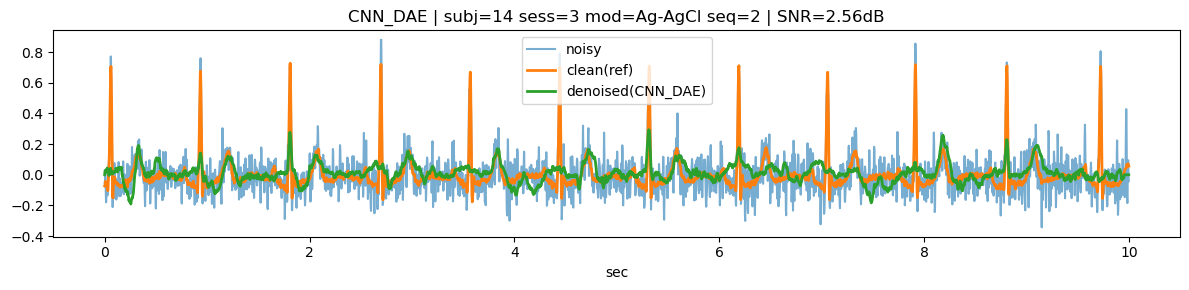

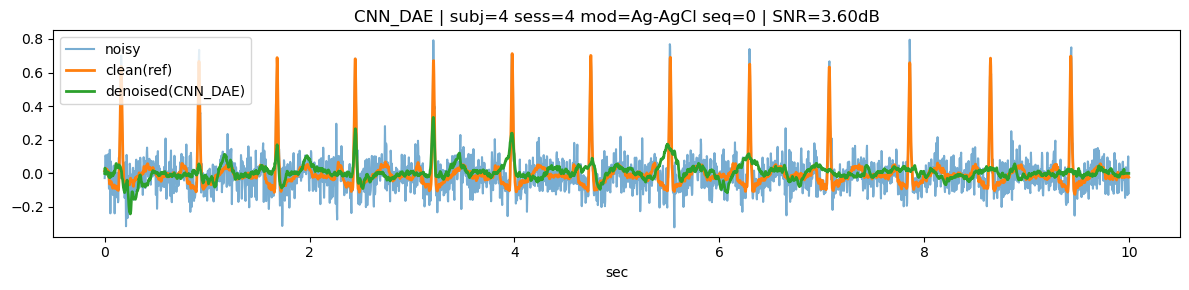

Plotting 10s examples for FCN_DAE


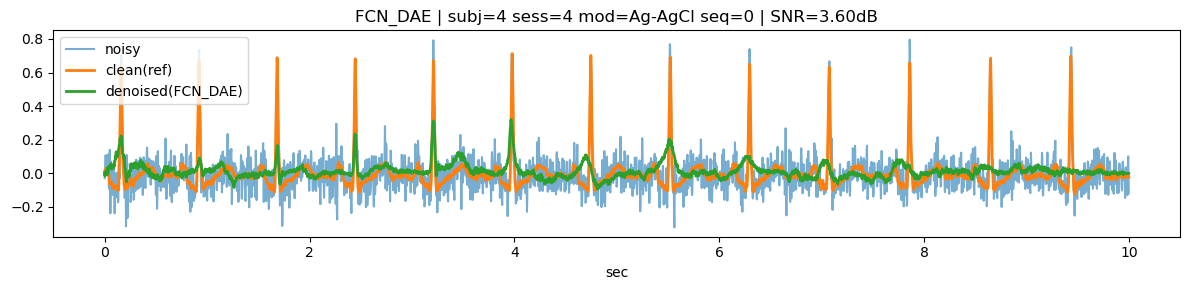

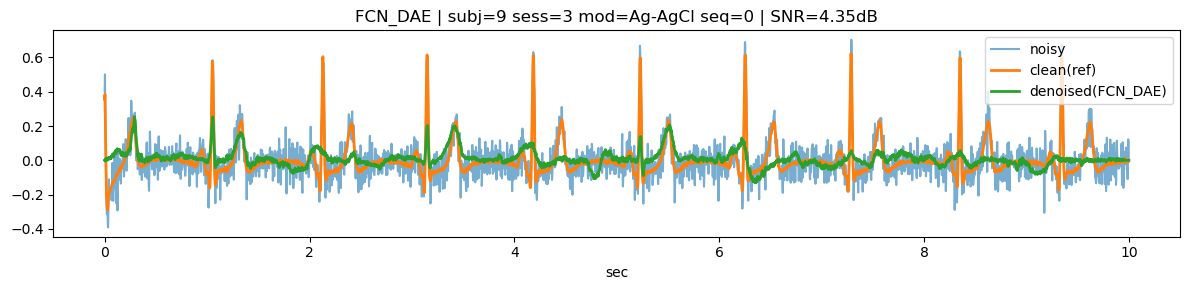

Plotting 10s examples for DRNN


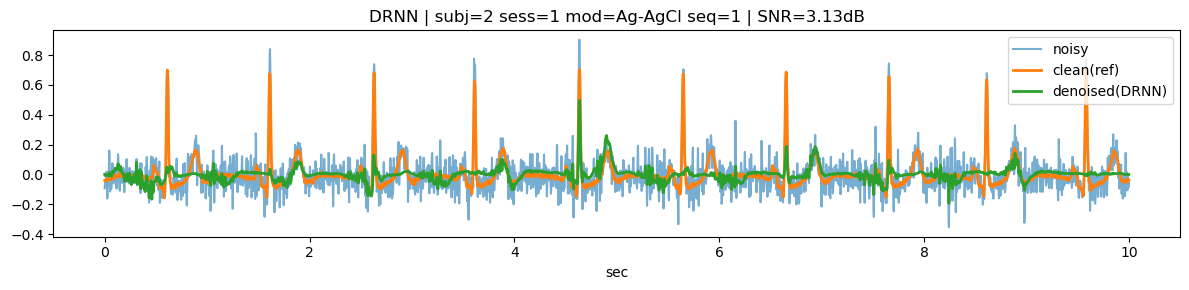

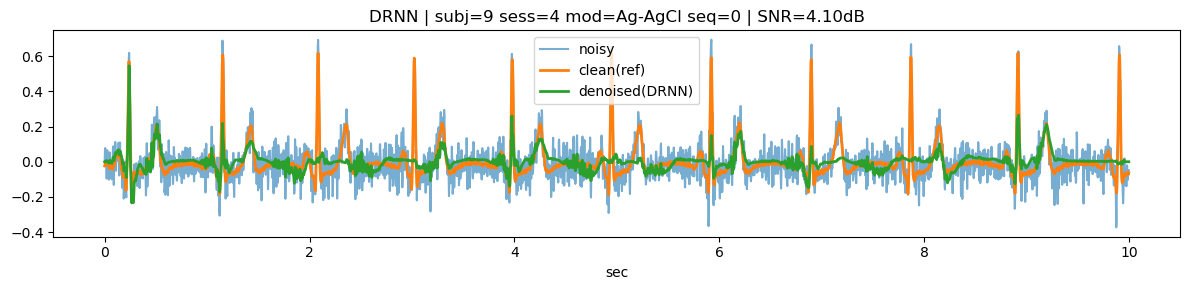

Plotting 10s examples for DeepFilter


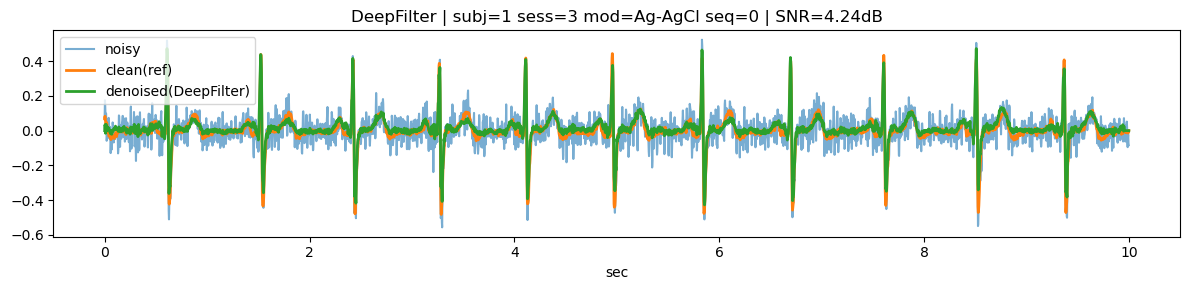

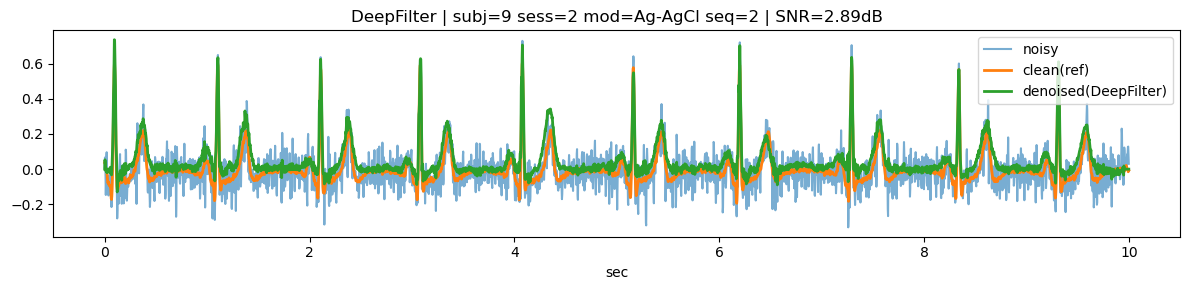

Plotting 10s examples for AttentionSkipDAE


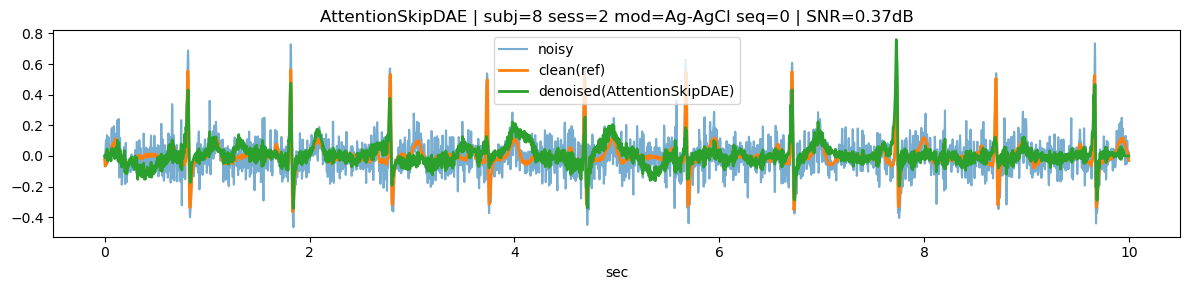

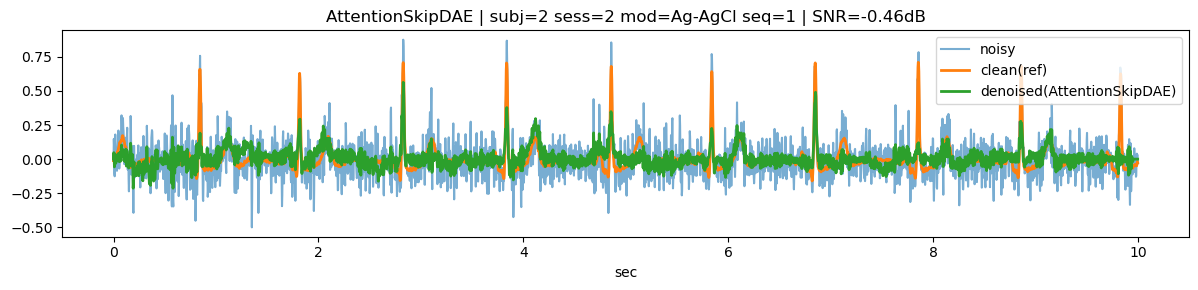

Plotting 10s examples for Transformer_DAE


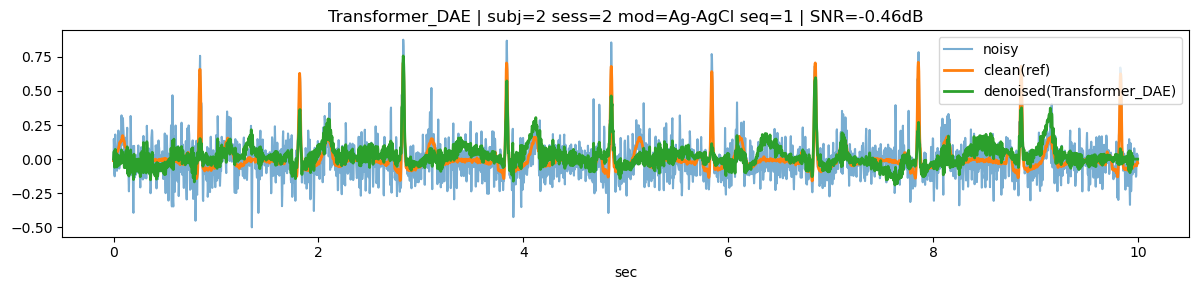

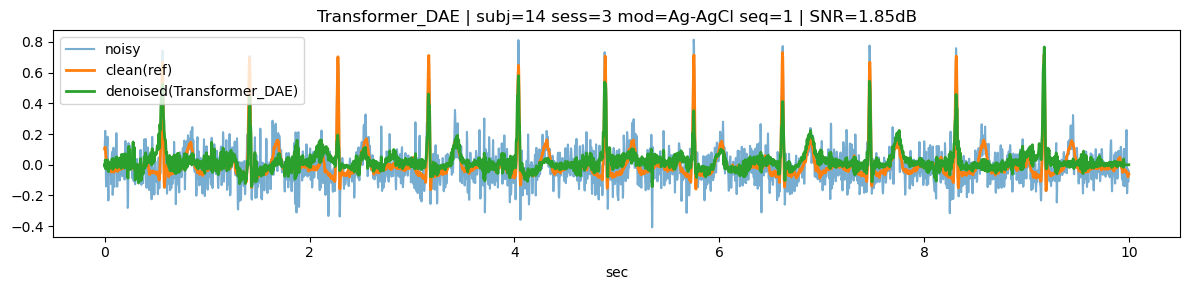

Plotting 10s examples for Dual_FreqDAE


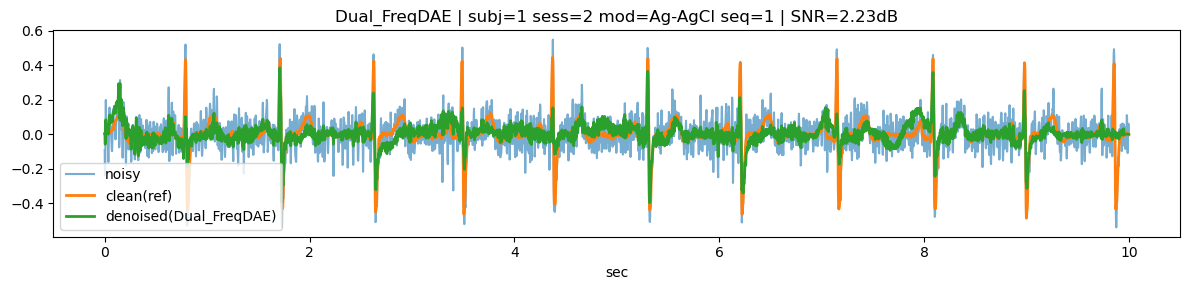

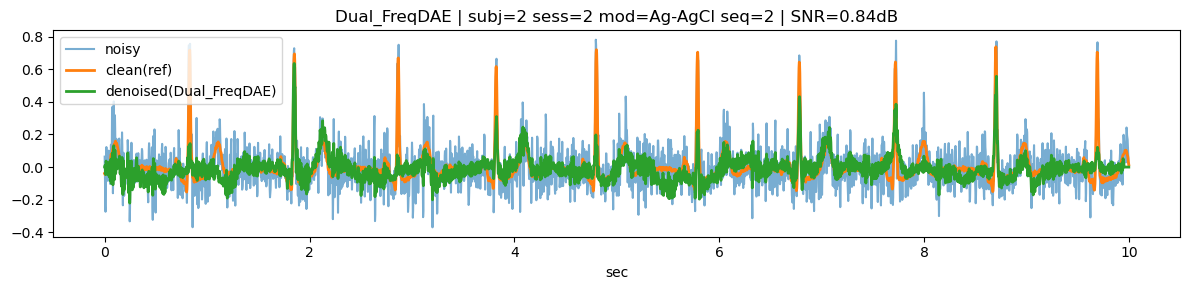

In [ ]:
# Quick visualization: per-model example plots (10s sequences; one modality)
modality_to_show = seq_meta["modality"].dropna().unique()[0] if seq_meta["modality"].notna().any() else None
print("Example modality:", modality_to_show)

for model_name in list(all_preds.keys()):
    print("Plotting 10s examples for", model_name)
    plot_denoise_examples_10s(model_name, all_preds[model_name], seq_meta, n=2, modality=modality_to_show)

## What we did (summary) + extra plots

> 업데이트 날짜: 2025-12-23

### What changed
- **TFCDiff-style evaluation**로 맞추기 위해 SimEMG를 **10초 시퀀스(360Hz → 3600 samples)** 단위로 평가.
- 입력 길이 512만 받는 모델들은 **sliding window (512, hop=256) + overlap-add**로 10초 전체 복원 후 지표 계산.
- **Dual_FreqDAE 전용 입력(Fourier)** 생성은 repo의 `make_fourier()`를 사용.
- Dual_FreqDAE의 성능 저하 원인이 전처리 mismatch인지 보기 위해 baseline-centering / Fourier-source ablation을 추가.
- 도메인 갭을 줄이기 위해 **leave-subject-out few-shot fine-tuning**을 추가(랜덤 512-window 샘플링).

### Key outcome (current run)
- Holdout subject = **2**, test sequences = **30**
- Zero-shot → Few-shot (3 epochs)에서 **SNR(dB) +2.43** 개선 (약 1.95 → 4.37dB).

Below plots make this improvement easier to justify in the rebuttal (distribution + examples + comparison).

In [ ]:
# Extra plots for few-shot section
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


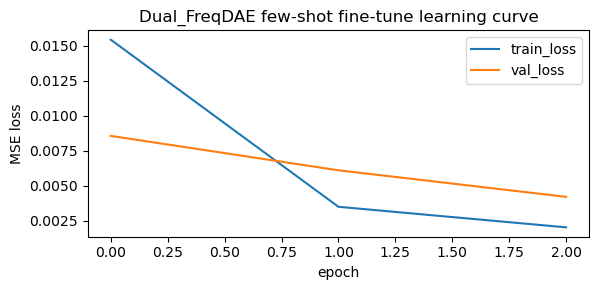

In [ ]:
# 1) Training curve (few-shot fine-tuning)
if 'hist' in globals() and hasattr(hist, 'history'):
    h = hist.history
    plt.figure(figsize=(6, 3))
    plt.plot(h.get('loss', []), label='train_loss')
    if 'val_loss' in h:
        plt.plot(h.get('val_loss', []), label='val_loss')
    plt.xlabel('epoch')
    plt.ylabel('MSE loss')
    plt.title('Dual_FreqDAE few-shot fine-tune learning curve')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No training history found (run the few-shot fit cell first).")


,snr_noisy_db,snr_zero_db,snr_few_db,rmse_zero,rmse_few,prd_zero,prd_few,cos_zero,cos_few,delta_snr_db,delta_rmse,delta_prd,delta_cos,subject,session,modality,seq_idx
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.0,30.00000,30,30.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ag-AgCl,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,NaN
mean,1.586732,1.949590,4.374789,0.079972,0.060455,80.019524,60.484397,0.622834,0.807332,2.425199,-0.019517,-19.535127,0.184499,2.0,3.00000,NaN,1.000000
std,1.479519,0.493871,0.371921,0.005103,0.003265,4.519330,2.569001,0.042798,0.024529,0.422280,0.003772,3.735358,0.038854,0.0,1.43839,NaN,0.830455
min,-0.661276,1.064713,3.897151,0.072292,0.055902,71.753024,56.109778,0.537802,0.772468,1.280734,-0.025201,-25.146856,0.100888,2.0,1.00000,NaN,0.000000
25%,0.241352,1.583687,4.026106,0.075100,0.057250,77.581540,58.043161,0.587992,0.786527,2.177497,-0.021859,-21.600111,0.156276,2.0,2.00000,NaN,0.000000
50%,2.076886,1.981304,4.236916,0.080193,0.061107,79.604091,61.397998,0.623761,0.800718,2.502070,-0.020596,-20.732041,0.197576,2.0,3.00000,NaN,1.000000
75%,2.847836,2.204832,4.725008,0.084333,0.063024,83.332828,62.906387,0.649787,0.830423,2.707567,-0.016404,-17.268082,0.217680,2.0,4.00000,NaN,2.000000


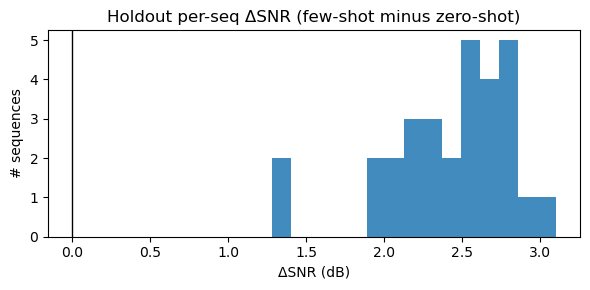

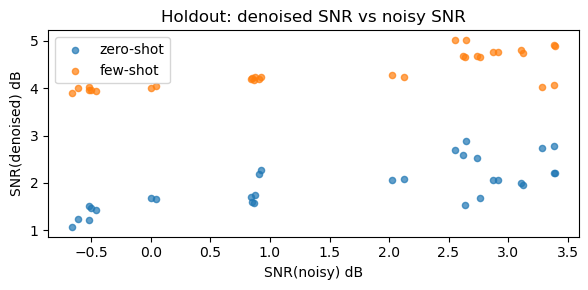

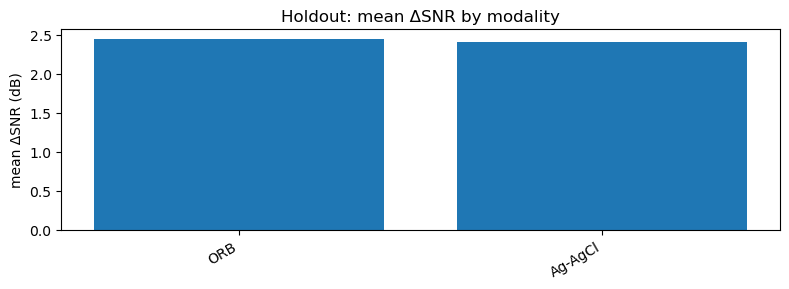

In [ ]:
# 2) Per-sequence improvement distribution (holdout subject)
if 'mdf_zero' in globals() and 'mdf_ft' in globals():
    df0 = mdf_zero.reset_index(drop=True).copy()
    dff = mdf_ft.reset_index(drop=True).copy()
    if len(df0) != len(dff):
        raise RuntimeError(f"mdf_zero and mdf_ft length mismatch: {len(df0)} vs {len(dff)}")

    cmp = pd.DataFrame({
        'snr_noisy_db': df0['snr_noisy_db'].to_numpy(),
        'snr_zero_db': df0['snr_denoised_db'].to_numpy(),
        'snr_few_db': dff['snr_denoised_db'].to_numpy(),
        'rmse_zero': df0['rmse_denoised'].to_numpy(),
        'rmse_few': dff['rmse_denoised'].to_numpy(),
        'prd_zero': df0['prd_denoised'].to_numpy(),
        'prd_few': dff['prd_denoised'].to_numpy(),
        'cos_zero': df0['cos_denoised'].to_numpy(),
        'cos_few': dff['cos_denoised'].to_numpy(),
    })
    cmp['delta_snr_db'] = cmp['snr_few_db'] - cmp['snr_zero_db']
    cmp['delta_rmse'] = cmp['rmse_few'] - cmp['rmse_zero']
    cmp['delta_prd'] = cmp['prd_few'] - cmp['prd_zero']
    cmp['delta_cos'] = cmp['cos_few'] - cmp['cos_zero']

    # attach modality/session metadata if available
    if 'test_meta' in globals():
        meta_show = test_meta.reset_index(drop=True).copy()
        for c in ['subject', 'session', 'modality', 'seq_idx']:
            if c in meta_show.columns:
                cmp[c] = meta_show[c].to_numpy()

    display(cmp.describe(include='all'))

    plt.figure(figsize=(6, 3))
    plt.hist(cmp['delta_snr_db'], bins=15, alpha=0.85)
    plt.axvline(0, color='k', linewidth=1)
    plt.title('Holdout per-seq ΔSNR (few-shot minus zero-shot)')
    plt.xlabel('ΔSNR (dB)')
    plt.ylabel('# sequences')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.scatter(cmp['snr_noisy_db'], cmp['snr_zero_db'], s=20, alpha=0.7, label='zero-shot')
    plt.scatter(cmp['snr_noisy_db'], cmp['snr_few_db'], s=20, alpha=0.7, label='few-shot')
    plt.xlabel('SNR(noisy) dB')
    plt.ylabel('SNR(denoised) dB')
    plt.title('Holdout: denoised SNR vs noisy SNR')
    plt.legend()
    plt.tight_layout()
    plt.show()

    if 'modality' in cmp.columns:
        by_mod = (cmp.groupby('modality', as_index=False)['delta_snr_db'].mean()
                  .sort_values('delta_snr_db', ascending=False))
        plt.figure(figsize=(8, 3))
        plt.bar(by_mod['modality'].astype(str), by_mod['delta_snr_db'])
        plt.xticks(rotation=30, ha='right')
        plt.ylabel('mean ΔSNR (dB)')
        plt.title('Holdout: mean ΔSNR by modality')
        plt.tight_layout()
        plt.show()
else:
    print("Missing mdf_zero/mdf_ft; run zero-shot and few-shot cells first.")


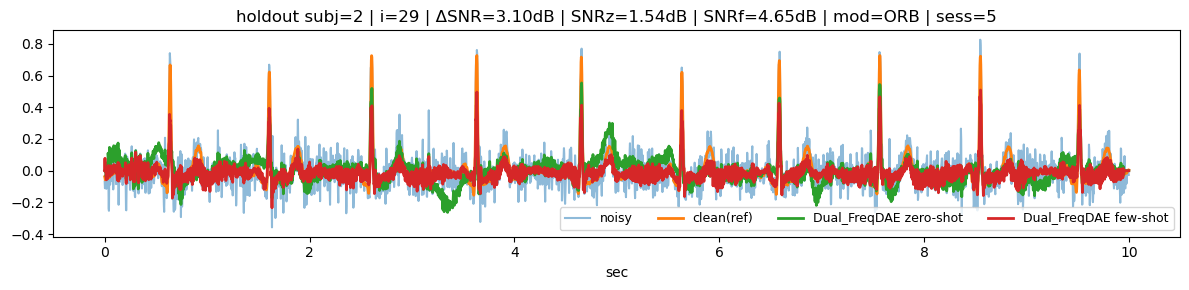

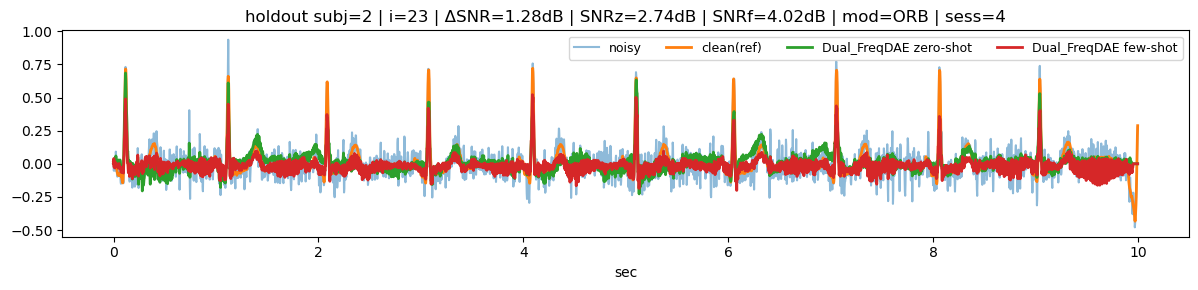

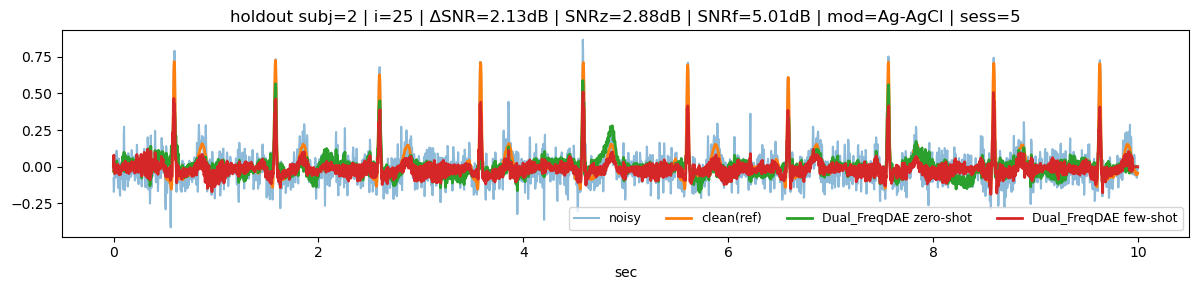

In [ ]:
# 3) Waveform examples: clean vs noisy vs zero-shot vs few-shot (holdout)
if all(k in globals() for k in ['Y_test_seq', 'X_test_seq', 'Yhat_zero', 'Yhat_ft']):
    L = Y_test_seq.shape[1]
    t = np.arange(L) / TARGET_FS

    # pick a few sequences: best ΔSNR, worst ΔSNR, and random
    if 'cmp' in globals():
        idx_best = int(cmp['delta_snr_db'].idxmax())
        idx_worst = int(cmp['delta_snr_db'].idxmin())
        idx_rand = int(np.random.default_rng(0).integers(0, len(Y_test_seq)))
        pick = [idx_best, idx_worst, idx_rand]
    else:
        pick = list(np.random.default_rng(0).choice(len(Y_test_seq), size=min(3, len(Y_test_seq)), replace=False))

    for i in pick:
        clean = Y_test_seq[i, :, 0]
        noisy = X_test_seq[i, :, 0]
        z = Yhat_zero[i, :, 0]
        f = Yhat_ft[i, :, 0]

        title_parts = [f"holdout subj={int(HOLDOUT_SUBJECT)}", f"i={i}"]
        if 'cmp' in globals():
            title_parts.append(f"ΔSNR={cmp.loc[i, 'delta_snr_db']:.2f}dB")
            title_parts.append(f"SNRz={cmp.loc[i, 'snr_zero_db']:.2f}dB")
            title_parts.append(f"SNRf={cmp.loc[i, 'snr_few_db']:.2f}dB")
        if 'test_meta' in globals() and i < len(test_meta):
            m = test_meta.reset_index(drop=True).iloc[i]
            if 'modality' in m:
                title_parts.append(f"mod={m['modality']}")
            if 'session' in m:
                title_parts.append(f"sess={m['session']}")

        plt.figure(figsize=(12, 3))
        plt.plot(t, noisy, label='noisy', alpha=0.5)
        plt.plot(t, clean, label='clean(ref)', linewidth=2)
        plt.plot(t, z, label='Dual_FreqDAE (pretrained)', linewidth=2)
        plt.plot(t, f, label='Dual_FreqDAE', linewidth=2)
        plt.title(' | '.join(title_parts))
        plt.xlabel('sec')
        plt.legend(ncol=4, fontsize=9)
        plt.tight_layout()
        plt.show()
else:
    print("Missing arrays for waveform plotting; run the evaluation cells first.")

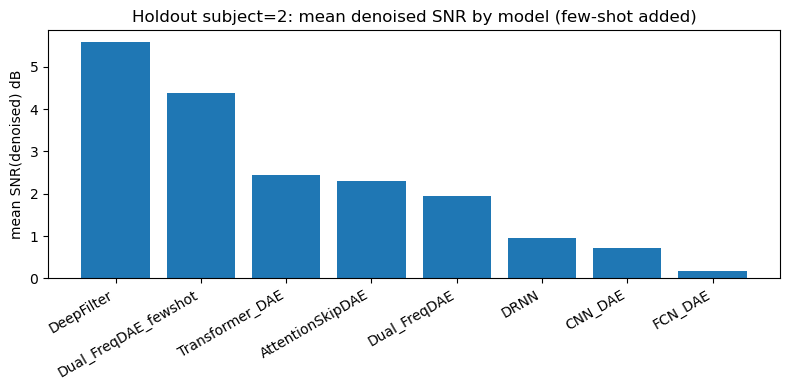

In [ ]:
# 4) Holdout subject comparison vs other zero-shot models (context plot)
if 'results_df' in globals() and 'summary_df' in globals():
    if 'subject' in results_df.columns:
        holdout_df = results_df[results_df['subject'].astype(int) == int(HOLDOUT_SUBJECT)].copy()
    else:
        holdout_df = results_df.copy()

    # mean denoised SNR per model on the holdout subject
    z = (holdout_df.groupby('model', as_index=False)['snr_denoised_db'].mean()
         .rename(columns={'snr_denoised_db': 'snr_denoised_db_mean'}))

    # rename pretrained Dual_FreqDAE to avoid confusion with fine-tuned model label
    z['model'] = z['model'].astype(str).replace({'Dual_FreqDAE': 'Dual_FreqDAE (pretrained)'})

    # add few-shot as a pseudo-model row (label as Dual_FreqDAE, per request)
    few_row = pd.DataFrame([{
        'model': 'Dual_FreqDAE',
        'snr_denoised_db_mean': float(summary_df.loc[summary_df['stage']=='few_shot','snr_denoised_db_mean'].iloc[0]),
    }])
    z = pd.concat([z, few_row], axis=0, ignore_index=True)
    z = z.sort_values('snr_denoised_db_mean', ascending=False)

    plt.figure(figsize=(8, 4))
    plt.bar(z['model'].astype(str), z['snr_denoised_db_mean'])
    plt.xticks(rotation=30, ha='right')
    plt.ylabel('mean SNR(denoised) dB')
    plt.title(f'Holdout subject={int(HOLDOUT_SUBJECT)}: mean denoised SNR by model (few-shot added)')
    plt.tight_layout()
    plt.show()
else:
    print("Missing results_df/summary_df; run the evaluation cells first.")

## Signal plotting (model-by-model)
같은 10초 시퀀스 인덱스에 대해 **모델별로** `noisy / clean(ref) / denoised`를 **따로(3행)** 그려서 비교합니다.

In [ ]:
def plot_triplet_noisy_clean_denoised(
    idx: int,
    model_name: str,
    y_hat_seq: np.ndarray,
    meta_df: pd.DataFrame,
    fs: int = TARGET_FS,
    show_title: bool = True,
    ylim_mode: str = "shared",
    figsize: tuple[int, int] = (12, 5),
    *,
    idx_pred: int | None = None,
    noisy_seq: np.ndarray | None = None,
    clean_seq: np.ndarray | None = None,
    y_hat_is_single: bool = False,
 ):
    """Plot noisy / clean / denoised separately (3 rows) for a single 10s sequence index.

    Notes
    -----
    - `idx` indexes the *reference* sequences (noisy/clean/meta).
    - `idx_pred` (optional) indexes the prediction array `y_hat_seq` when it is a subset (e.g., holdout-only).
    - If `y_hat_is_single=True`, `y_hat_seq` is treated as a single 1D/2D sequence (not a batch).
    """
    if noisy_seq is None:
        noisy_seq = X_noisy_seq
    if clean_seq is None:
        clean_seq = Y_clean_seq
    if idx_pred is None:
        idx_pred = idx
    if idx < 0 or idx >= len(meta_df):
        raise IndexError(f"idx out of range: {idx}")
    if y_hat_is_single:
        den = np.asarray(y_hat_seq)
    else:
        if idx_pred < 0 or idx_pred >= np.asarray(y_hat_seq).shape[0]:
            raise IndexError(f"idx_pred out of range: {idx_pred} (pred batch={np.asarray(y_hat_seq).shape[0]})")
        den = y_hat_seq[idx_pred]
    # flatten channel dims if present
    clean = np.asarray(clean_seq[idx]).squeeze()
    noisy = np.asarray(noisy_seq[idx]).squeeze()
    den = np.asarray(den).squeeze()
    t = np.arange(len(clean)) / fs

    if ylim_mode == "shared":
        y_min = float(np.min([clean.min(), noisy.min(), den.min()]))
        y_max = float(np.max([clean.max(), noisy.max(), den.max()]))
        pad = 0.05 * (y_max - y_min + 1e-9)
        ylim = (y_min - pad, y_max + pad)
    else:
        ylim = None

    m = meta_df.iloc[idx]
    title_bits = [str(model_name)]
    for k in ["subject", "session", "modality", "seq_idx"]:
        if k in meta_df.columns:
            title_bits.append(f"{k}={m.get(k)}")
    if "snr_noisy_db" in meta_df.columns:
        try:
            title_bits.append(f"SNR(noisy)={float(m.get('snr_noisy_db')):.2f}dB")
        except Exception:
            pass

    fig, axs = plt.subplots(3, 1, sharex=True, figsize=figsize)
    axs[0].plot(t, noisy, color="#1f77b4")
    axs[0].set_ylabel("noisy")
    axs[1].plot(t, clean, color="#ff7f0e")
    axs[1].set_ylabel("clean(ref)")
    axs[2].plot(t, den, color="#2ca02c")
    axs[2].set_ylabel("denoised")
    axs[2].set_xlabel("sec")
    if ylim is not None:
        for ax in axs:
            ax.set_ylim(*ylim)
    if show_title:
        fig.suptitle(" | ".join(title_bits), y=0.98)
    plt.tight_layout()
    plt.show()


IDX_COMPARE: 69
meta:


,row,subject,session,modality,path,seq_idx,seq_sec,snr_noisy_db
69,59,2,5,Ag-AgCl,/home/dhc99/ecg_denoise/data/SimEMG/P2_5_Ag-Ag...,0,10,-0.523519


Model: CNN_DAE


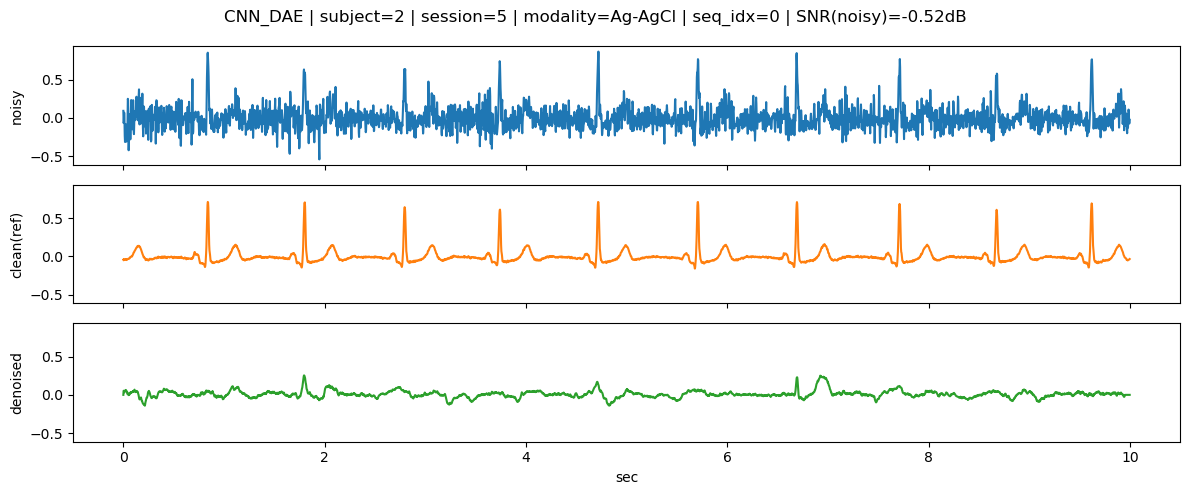

Model: FCN_DAE


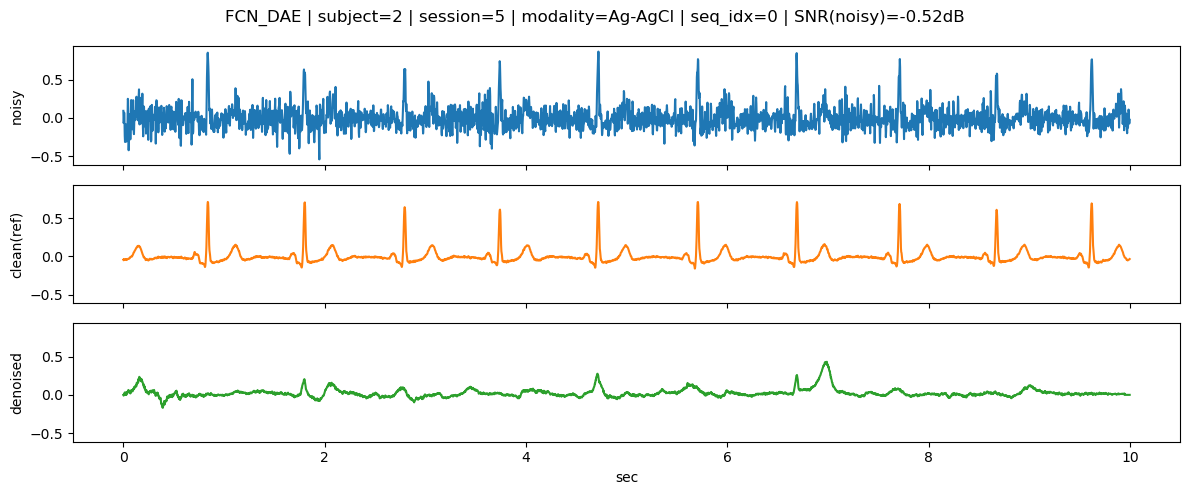

Model: DRNN


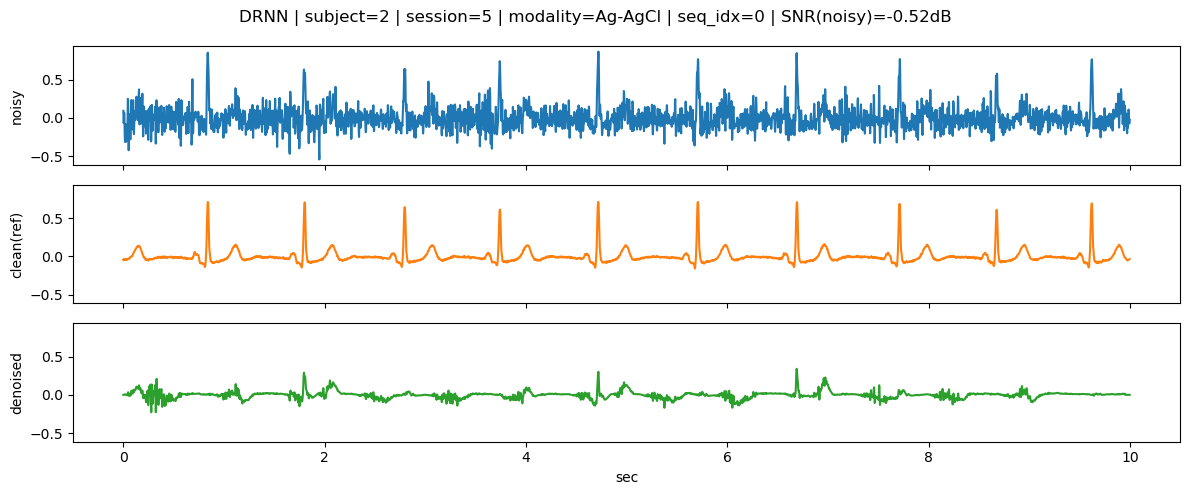

Model: DeepFilter


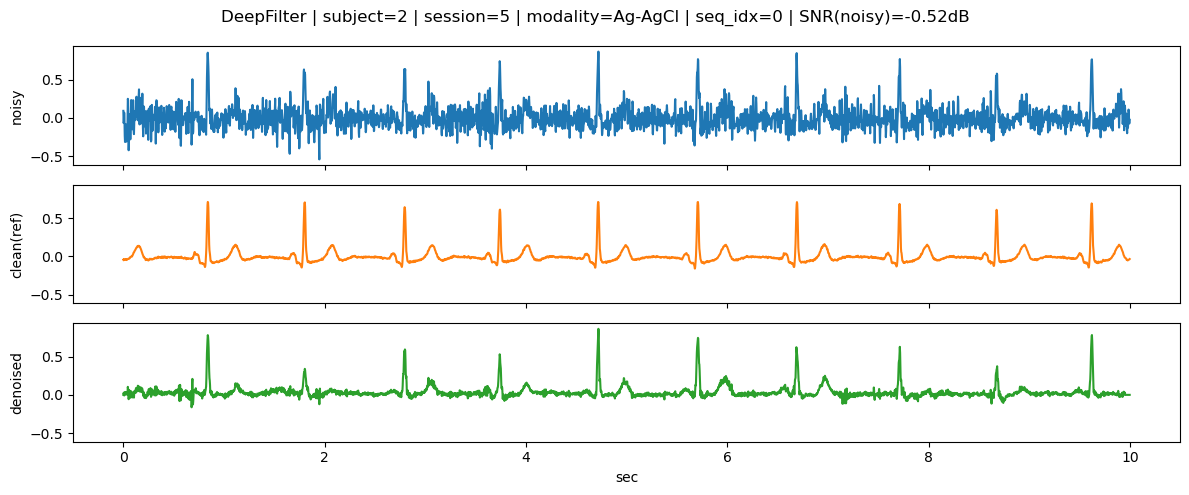

Model: AttentionSkipDAE


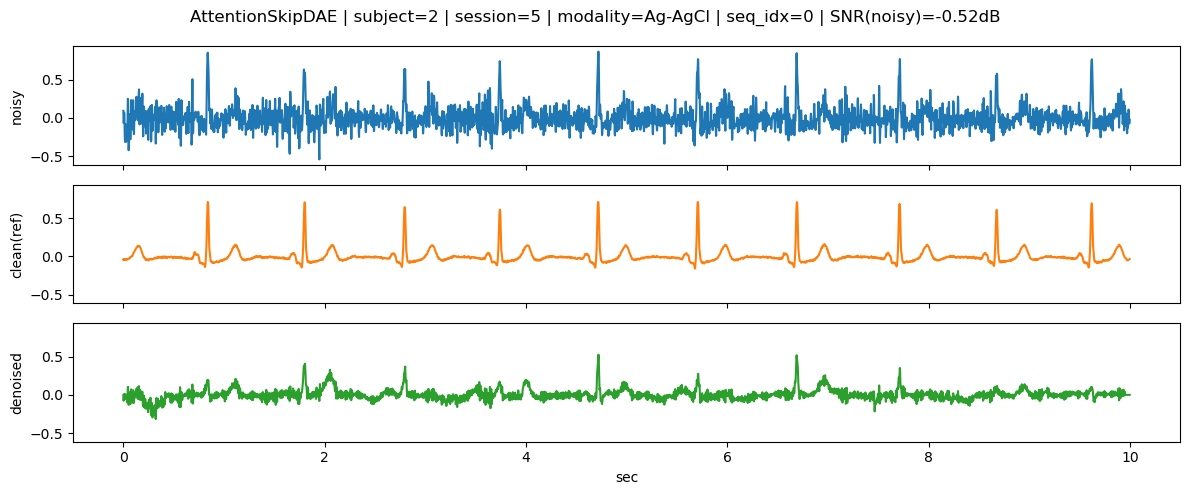

Model: Transformer_DAE


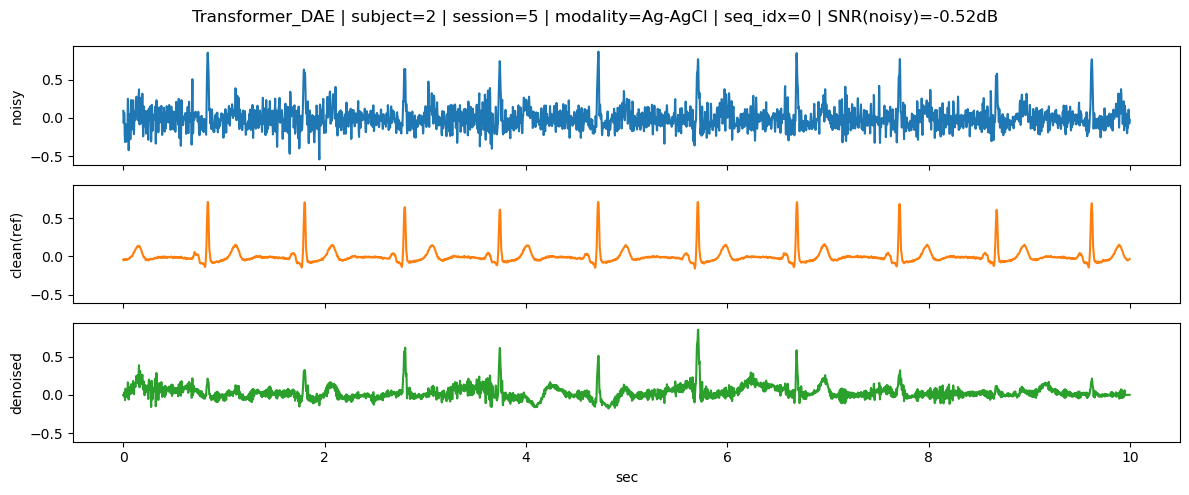

Model: Dual_FreqDAE (pretrained)


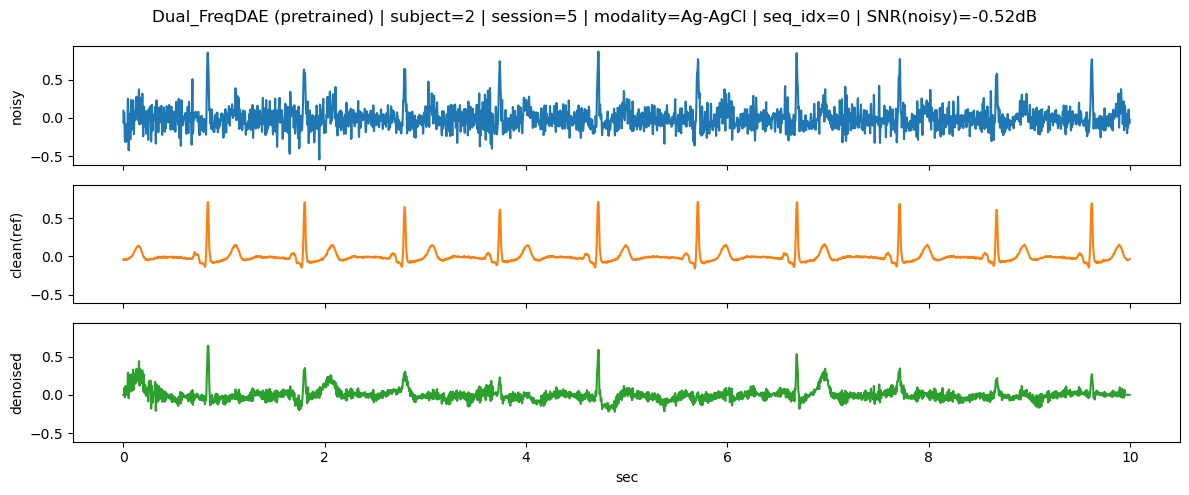

Model: Dual_FreqDAE


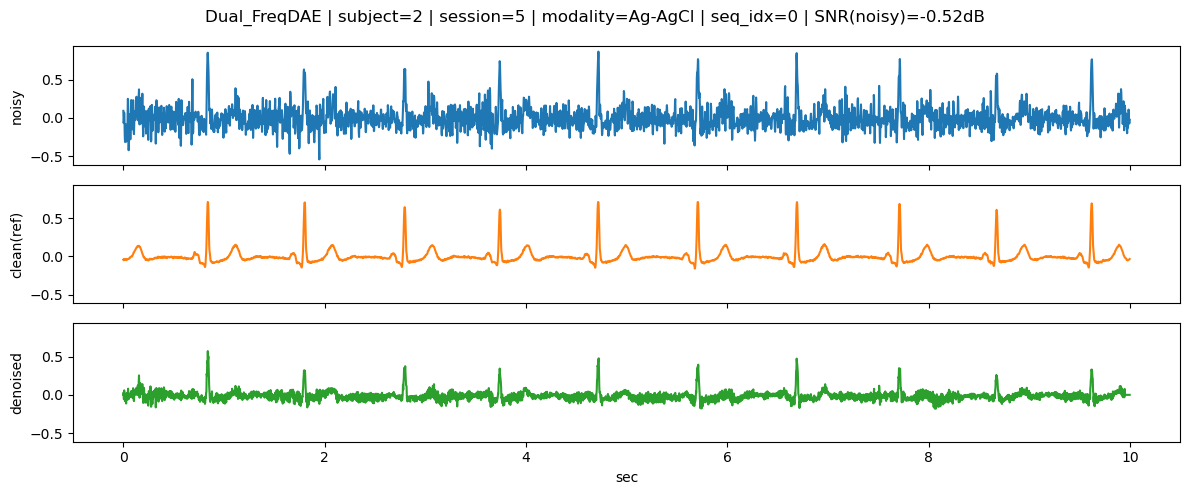

: 

In [ ]:
# Choose a single sequence index to compare across models (including Dual_FreqDAE few-shot)
if 'seq_meta' not in globals() or 'all_preds' not in globals():
    print("Missing seq_meta/all_preds. Run the 10s evaluation section first.")
else:
    meta_plot = seq_meta.reset_index(drop=True)
    n_seq = len(meta_plot)
    if n_seq == 0:
        raise ValueError("seq_meta is empty")

    # If few-shot predictions exist, restrict the pool to the holdout subject sequences.
    # IMPORTANT: keep an unfiltered global-index list for mapping (pred_global_index), because modality filtering shrinks idx_pool_global.
    idx_pool_global = np.arange(n_seq)
    pred_global_index = None
    if 'Yhat_ft' in globals() and Yhat_ft is not None:
        if 'holdout_mask' in globals() and holdout_mask is not None:
            hm = np.asarray(holdout_mask).astype(bool)
            if hm.shape[0] == n_seq:
                pred_global_index = np.flatnonzero(hm)
                idx_pool_global = pred_global_index.copy()
        if pred_global_index is None and 'test_idx' in globals() and test_idx is not None:
            pred_global_index = np.asarray(test_idx).astype(int)
            idx_pool_global = pred_global_index.copy()
        if pred_global_index is None:
            # fall back: at least keep indices within the few-shot batch size
            idx_pool_global = np.arange(min(n_seq, int(np.asarray(Yhat_ft).shape[0])))
            pred_global_index = idx_pool_global.copy()

    # Optional modality filter (applies only to the selection pool; mapping still uses pred_global_index)
    if 'modality_to_show' in globals() and modality_to_show is not None and 'modality' in meta_plot.columns:
        mod_mask = (meta_plot['modality'].to_numpy() == modality_to_show)
        idx_pool_global = idx_pool_global[mod_mask[idx_pool_global]]
        if len(idx_pool_global) == 0:
            idx_pool_global = np.arange(n_seq)

    IDX_COMPARE = int(np.random.default_rng(0).choice(idx_pool_global, size=1)[0])
    print("IDX_COMPARE:", IDX_COMPARE)
    print("meta:")
    display(meta_plot.iloc[[IDX_COMPARE]])

    # Build a plotting dict that includes both Dual_FreqDAE (pretrained) and few-shot (titled as "Dual_FreqDAE")
    preds_for_plot: dict[str, np.ndarray] = {}
    for model_name, y_hat_seq in all_preds.items():
        if model_name == "Dual_FreqDAE":
            preds_for_plot["Dual_FreqDAE (pretrained)"] = y_hat_seq
        else:
            preds_for_plot[model_name] = y_hat_seq

    # If explicit arrays exist, prefer them
    if 'Yhat_zero' in globals() and Yhat_zero is not None:
        preds_for_plot["Dual_FreqDAE (pretrained)"] = Yhat_zero
    if 'Yhat_ft' in globals() and Yhat_ft is not None:
        # IMPORTANT: title should NOT mention few-shot → use plain "Dual_FreqDAE"
        preds_for_plot["Dual_FreqDAE"] = Yhat_ft

    preferred_order = [
        "CNN_DAE", "FCN_DAE", "DRNN", "DeepFilter", "AttentionSkipDAE", "Transformer_DAE",
        "Dual_FreqDAE (pretrained)", "Dual_FreqDAE",
    ]
    remaining = [k for k in preds_for_plot.keys() if k not in preferred_order]
    plot_order = [k for k in preferred_order if k in preds_for_plot] + remaining

    # Map global index → prediction index if predictions are for a subset
    idx_pool_global = np.asarray(idx_pool_global).astype(int)
    if pred_global_index is not None:
        pred_global_index = np.asarray(pred_global_index).astype(int)

    def _idx_pred_for(y_hat: np.ndarray, idx_global: int) -> int:
        y_hat = np.asarray(y_hat)
        if y_hat.ndim == 1:
            return 0
        if y_hat.shape[0] == n_seq:
            return idx_global
        # preferred: map via the unfiltered holdout/test global-index list
        if pred_global_index is not None and y_hat.shape[0] == len(pred_global_index):
            hit = np.flatnonzero(pred_global_index == idx_global)
            if len(hit) == 0:
                raise IndexError("idx_global not in pred_global_index")
            return int(hit[0])
        # fallback: map via the (possibly filtered) selection pool
        if y_hat.shape[0] == len(idx_pool_global):
            hit = np.flatnonzero(idx_pool_global == idx_global)
            if len(hit) == 0:
                raise IndexError("idx_global not in subset pool")
            return int(hit[0])
        # last resort: allow direct indexing if it fits
        if idx_global < y_hat.shape[0]:
            return idx_global
        raise IndexError(f"idx {idx_global} out of bounds for pred batch size {y_hat.shape[0]}")

    # plot for each model: (noisy/clean/denoised) separately
    for model_name in plot_order:
        y_hat_seq = preds_for_plot[model_name]
        print("Model:", model_name)
        try:
            idx_pred = _idx_pred_for(y_hat_seq, IDX_COMPARE)
            plot_triplet_noisy_clean_denoised(
                idx=IDX_COMPARE,
                idx_pred=idx_pred,
                model_name=model_name,
                y_hat_seq=y_hat_seq,
                meta_df=meta_plot,
                fs=TARGET_FS,
                noisy_seq=X_noisy_seq,
                clean_seq=Y_clean_seq,
            )
        except Exception as e:
            print(f"[WARN] plot failed for {model_name}: {e}")
